# Lesson 122 · REG construction: from database keys to a verified graph

Teacher reference · Three live functions construct the toy and complete released F1 topology. PROVIDED = inspect; TODO = implement; CHECK = execute unchanged; EXIT = defend. Default execution rebuilds every key row and rescores author predictions; full GPU training is separately gated. Learner status PENDING_WRITTEN_DEFENSE.

In [1]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


Actual notebook runtime: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'numpy': '2.5.0', 'pandas': '3.0.3', 'torch': '2.13.0+cpu', 'pytorch-frame': '0.3.0', 'torch-geometric': '2.8.0.post1', 'relbench': '1.1.0'}


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 121 to this lesson</p>
<p>The historical comparison showed that representation matters. Start the modern pipeline by preserving row identities and relationship roles exactly.</p>
<details><summary>Quick prerequisite reminder</summary><p>Raw keys name entities; local indices address tensor rows. An edge tensor has a sender row and a receiver row. Reverse relations change message direction, not the original database fact.</p></details>
</aside>
<!-- sequence-review:end -->



## One tangible win

Given tables and their declared keys, build a graph whose nodes, typed edges, and row features you can trace back to the database. Prove that construction against an independent relational join. You should be able to explain **why each edge exists**, not just print a `HeteroData` object.

[Lesson 121](https://avistian.github.io/relational/lessons/0121-history-relational-ml.html) asked which relational information a representation preserves. This lesson makes that question executable: preserve row identity and declared relationships before learning weights. Recall [L096](https://avistian.github.io/relational/lessons/0096-multi-relational-data.html) and [L117](https://avistian.github.io/relational/lessons/0117-rdl-bridge.html), then work through a small database where using raw IDs as tensor indices fails visibly. L123 adds time-respecting sampling; L124 separates entity tables from prediction queries; L125 deepens row encoding.

**Read:** [Fey et al., ICML 2024, §3.1–3.2 and Figure 4](https://proceedings.mlr.press/v235/fey24a.html), then inspect the [pinned RelBench graph constructor](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/graph.py). The former defines the representation; the latter specifies executable choices. The score reproduction below is a named experiment from the separate RelBench v1 paper.



## 1 · Three graphs answer three different questions

A **schema graph** has a node per table: it says which kinds of entities can be connected. A **relational entity graph (REG)** expands each table into its individual rows. A **computation graph** selects the context used for one prediction, under a sampling and temporal contract. Building the second does not establish that the third is valid for a historical query. [Fey §3](https://proceedings.mlr.press/v235/fey24a.html).

In the core mapping, each table supplies a node type; each row supplies one node of that type; a non-null foreign key points to the matching parent row. The implementation stores both message directions explicitly. Nothing has been trained yet. A representation determines what information a later learner can access; its usefulness still requires evaluation.

**Predict:** if a person has no transactions, how many person nodes should disappear? Zero. Node existence follows table membership, not observed degree. Inferring `num_nodes` from the largest edge index can erase isolated trailing rows.



## 2 · Raw identity is not a tensor coordinate

Use this entire example; do not mentally sort it.

| Person row | id (PK) | age |
|---:|---:|---:|
| 0 | 90 | 40 |
| 1 | 10 | 20 |
| 2 | 300 | 60 |

| Transfer row | id (PK) | sender (FK) | receiver (FK) | amount |
|---:|---:|---:|---:|---:|
| 0 | 7 | 10 | 90 | 5 |
| 1 | 8 | 90 | 10 | 8 |
| 2 | 9 | NULL | 90 | 2 |

The person lookup is `{90: 0, 10: 1, 300: 2}`. Transfer7's sender key10 resolves to **person row1**; its receiver key90 resolves to **person row0**. Transfer7 itself is **transfer row0**. These coordinates belong to separate node stores.

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">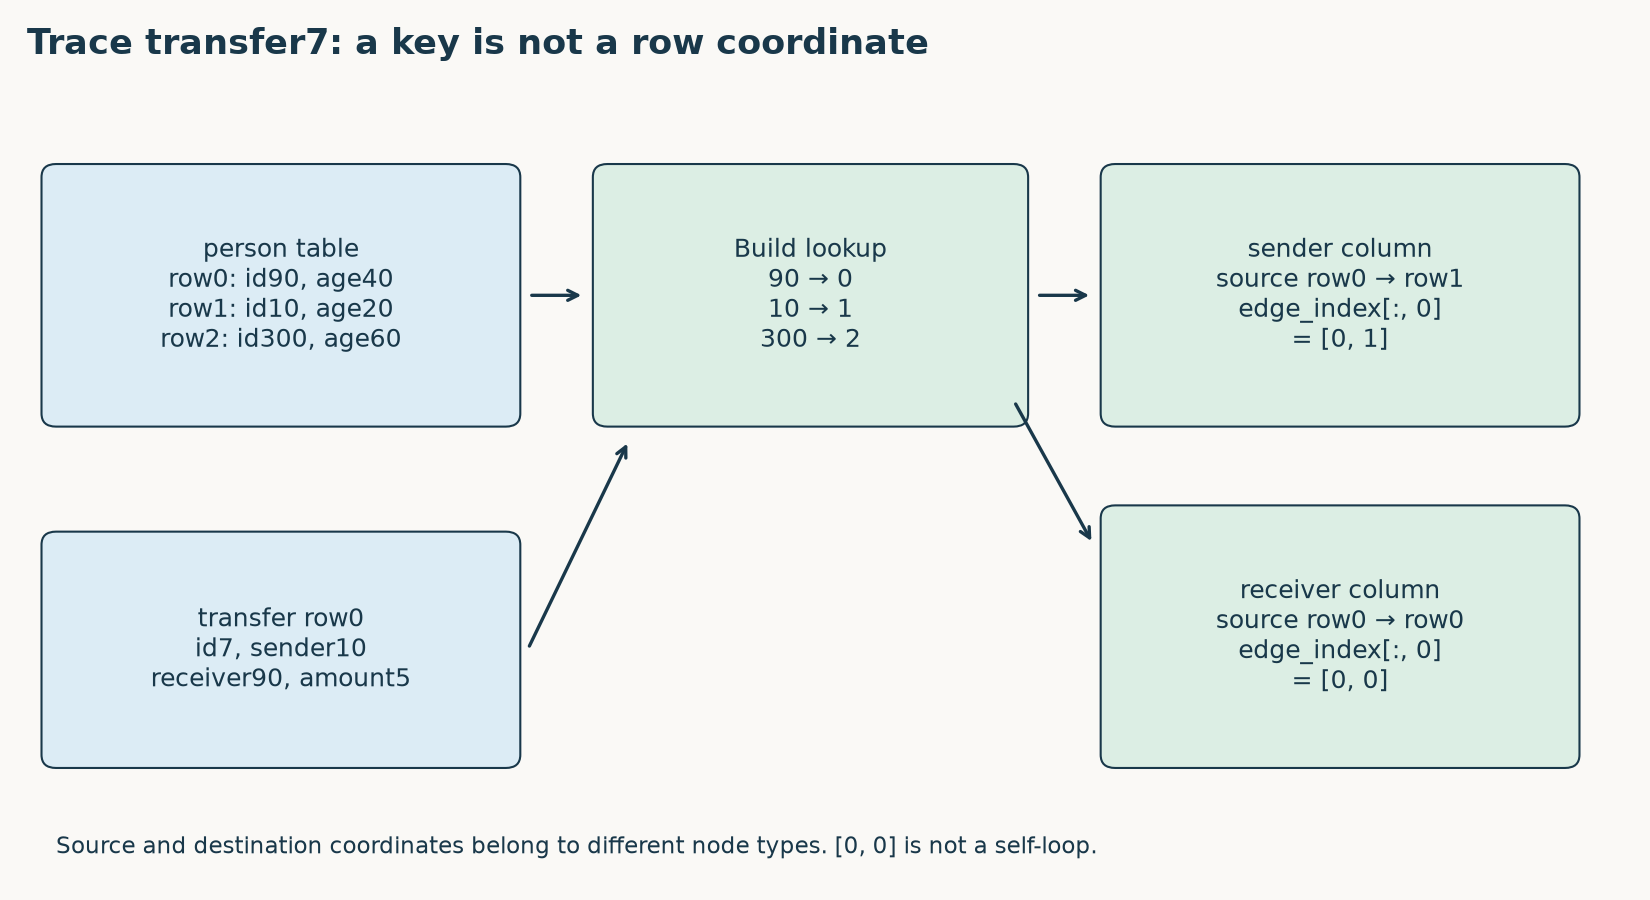<figcaption>Transfer7 maps sender key10 to person row1 and receiver key90 to person row0. Coordinates are local to each node type.</figcaption></figure>

```python
lookup = {key: row for row, key in enumerate(primary_keys)}
# transfer row0 has receiver key90:
source_row = 0
destination_row = lookup[90]  # 0
```

This fragment explains lookup, but production construction also rejects duplicate or null primary keys. Otherwise one database identity can map ambiguously, and a dictionary silently keeps only the last occurrence. Our first notebook task implements the validated lookup.

A relation's `edge_index` has shape **[2, E]**: each column holds `[source_row, destination_row]`. For receivers, the complete tensor is `[[0, 1, 2], [0, 1, 0]]`. Column `[0,0]` connects transfer row0 to person row0. It is **not a self-loop**: the types differ. These are PyG's source-to-destination coordinates; [HeteroData documentation](https://pytorch-geometric.readthedocs.io/en/2.6.1/generated/torch_geometric.data.HeteroData.html) defines separately indexed node and edge stores.

**CHECK before code:** permute person rows to `[300, 90, 10]`. The receiver destination row sequence becomes `[1,2,1]`. The underlying links still mean transfer7→person90, transfer8→person10, transfer9→person90. Reorder features consistently and rebuild every affected endpoint.



## 3 · Preserve relationship roles and reverse direction

Both `sender` and `receiver` refer to the person table. Collapsing them to a single relation loses their roles. The released implementation names a relation with its foreign-key column:

```python
kind = ('transfer', 'f2p_receiver', 'person')
data[kind].edge_index = receiver_edges
reverse = ('person', 'rev_f2p_receiver', 'transfer')
data[reverse].edge_index = receiver_edges.flip(0)
```

The sender relation has its own pair of stores. Thus this example has **two forward types and two reverse types**, with five forward edges and five reverse edges. A reverse edge supports message flow back along an existing relationship; it does not create a second observation or a new database foreign key. The paper's schematic type notation is simpler than this released column-specific convention; keep the source convention explicit. [Pinned constructor](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/graph.py).

Now perform an untrained diagnostic: send each transfer's amount along its receiver edge and sum at each person. Person90 receives `5 + 2 = 7`; person10 receives `8`; person300 receives `0`. This small computation exposes whether you reversed the edge or confused sender with receiver. It is not a learned RDL prediction.

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">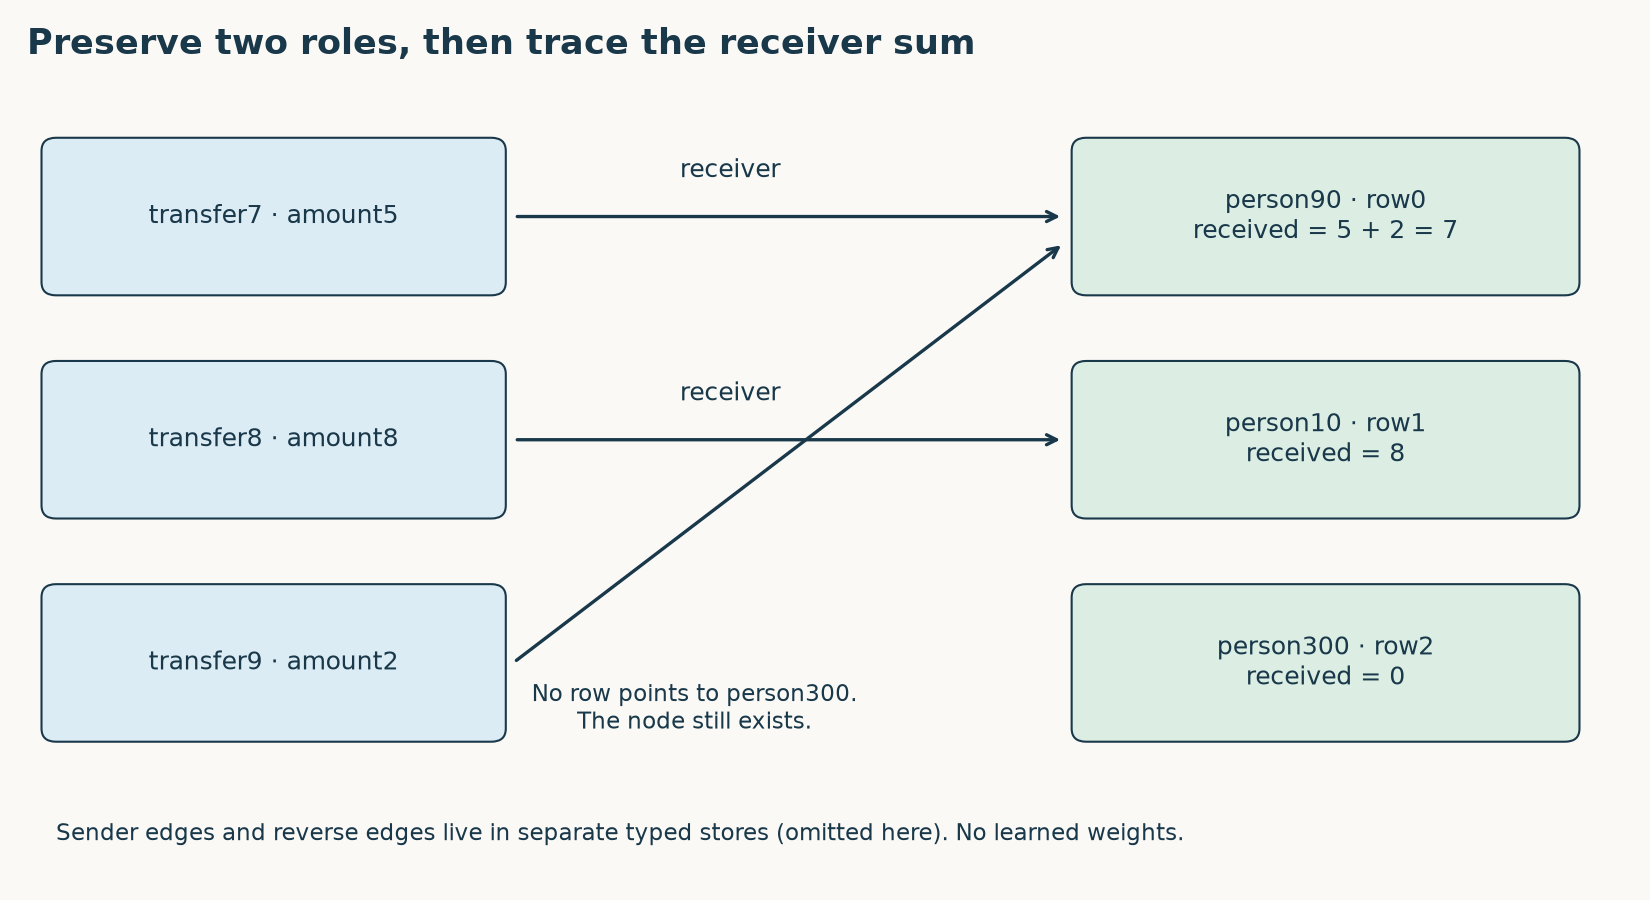<figcaption>The untrained receiver sum is [7,8,0]. Person300 remains a node despite having no incident edges.</figcaption></figure>

```python
received = torch.zeros(data['person'].num_nodes)
edge = data['transfer', 'f2p_receiver', 'person'].edge_index
received.index_add_(0, edge[1], amounts[edge[0]])
# [7., 8., 0.] in the original person-row order
```

**Predict the intervention:** changing transfer7's receiver from 90 to 10 moves five units from person90 to person10. The result becomes `[2,13,0]`; all sender edges and row features stay fixed.

Static trace: receiver key90 maps to person row0. Received amounts are [7,8,0]; changing that key to10 gives [2,13,0]. NULL removes only this edge; unknown key999 rejects construction.



## 4 · Missing relationships and repeated observations

A null foreign key means this column supplies no parent link. It does not delete the row, its features, or its other relations. Transfer9 has no sender edge but still has a receiver edge and an amount.

A **dangling key** is different: a non-null key refers to no parent in the declared input database. Our constructor raises an error. It does not silently discard the relationship. If a database snapshot intentionally removed the parent, decide and document the snapshot/remapping policy before construction. The released graph builder expects already-normalized keys; upstream dataset processing may have handled missing references before it runs. Our audit establishes the released input's identity, not the completeness of its original operational database.

A junction table also remains a node type. Two rows recording the same sender/receiver pair at different amounts or times are two observations. Projecting them into one person-to-person edge can erase multiplicity and row attributes. Any such projection needs its own representation contract; it is not this row-to-node REG.

**Task 2:** implement foreign-key resolution, preserving source-row positions when nulls occur in the middle. Return shape `[2,0]` for an empty relation. Reject missing parents and duplicate primary keys.



## 5 · Construct the graph, then encode its rows

**Task 3:** assemble `HeteroData` with explicit `num_nodes` for every table, a store per FK role, and its reverse. Return the non-key feature column names in their original order. The [visible constructor](https://avistian.github.io/relational/labs/relkit/reg_l122.py) is embedded into both notebooks; three task implementations feed the actual graph and diagnostic sum.

For our example, the person feature is `age` and the transfer feature is `amount`. Keys route relationships; their numerical magnitudes do not enter the released row encoder as continuous features. This is a particular modeling choice, not a theorem that every identifier lacks signal. [Released key removal and materialization](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/graph.py).

The teaching constructor separates topology from encoding: it returns feature names, not fitted embeddings. The full runner materializes typed columns into a `TensorFrame`, computes the released statistics, and applies learned per-table encoders. A table with no remaining feature columns receives a constant feature in the released implementation. Explicit `num_nodes` still preserves rows even without useful features. L125 studies this encoding boundary in detail.

**Temporal boundary:** the complete released F1 graph below includes data up to the benchmark's test cutoff. It is not wholly visible to every query. The full runner uses query-time sampling. Historical ingestion and mutable-feature histories are unavailable; static graph correctness cannot prove absence of temporal leakage. L123 will focus on this second contract.



## 6 · Audit a complete real database

The default notebook builds the small graph and reconstructs all released F1 key rows into a graph and audits its topology against independently verified edge pairs. The separate graph-audit command rebuilds that topology from the complete released database, calls our constructor, compares every edge with SQL, and invokes the original pinned graph constructor. It saves the full compact topology and a local loadable `HeteroData` artifact. This is the real relational-data exercise (Tier B); the tiny fixture isolates failure modes (Tier C).

**Full released F1 topology: PASS.** 74063 rows; 13 forward relation types; 338842 directed edges, including reverses.

| Table | Nodes |
|---|---:|
| constructor_results | 9,408 |
| constructor_standings | 10,170 |
| circuits | 77 |
| qualifying | 4,082 |
| drivers | 857 |
| results | 20,323 |
| races | 820 |
| standings | 28,115 |
| constructors | 211 |

Every forward endpoint matches an independent SQL join; reverse endpoints match after sorting. [Complete audit](https://avistian.github.io/relational/labs/_graph_audit_l122_results.json).

Counts alone are insufficient: two incorrect edge lists can have the same length. We compare exact endpoint pairs, distinguish edge-order conventions from semantics, and check every reverse edge. We also test permutation equivariance at the identity level, repeated endpoint observations, isolated rows, nulls, and missing parents.

**A valid tensor can encode the wrong database.** Keep the three transfer rows and person-row order from Section 2, but swap the receivers of transfers7 and8:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:.4em .25em"><thead><tr><th>Transfer key</th><th>Correct receiver key</th><th>Wrong receiver key</th></tr></thead><tbody><tr><td>7</td><td>90</td><td>10</td></tr><tr><td>8</td><td>10</td><td>90</td></tr><tr><td>9</td><td>90</td><td>90</td></tr></tbody></table>

The correct destination indices are `[0,1,0]`; the wrong ones are `[1,0,0]`. Both have three edges and receiver degrees `[2,1,0]`. All indices are in bounds. Rebuilding the reverse relation from the wrong tensor preserves the reverse-edge check too. PyG's [`validate`](https://pytorch-geometric.readthedocs.io/en/2.6.1/_modules/torch_geometric/data/hetero_data.html#HeteroData.validate) checks structural consistency; it does not have the original database foreign-key values to verify these links.

Decode each endpoint back to its raw key and compare the exact pairs with an independent SQL join. That rejects the swapped links. A count, degree sequence, or successful tensor operation would not.

**Try the diagnostic.** Send the original amounts `[5,8,2]` through the wrong receiver tensor. What changes? What if every amount were 1?

<details><summary>Check the swapped endpoints</summary><p>The wrong sum is [10,5,0], instead of [7,8,0]. With all amounts equal to 1, both graphs give [2,1,0], so this value diagnostic becomes blind to the mistake. The exact key-pair comparison still rejects it.</p></details>

The local original-code topology comparison uses constant features and omits time attributes because the historical helper attempts an in-place write to a read-only array under the current pandas runtime. This is recorded in the audit. Every GPU fit separately executes the full released feature/time path in the pinned runtime. The local topology check does not establish feature, timestamp, or score parity by itself.



## 7 · Follow the graph into the full selected reproduction

A graph audit alone does not reproduce a predictive result. To exercise the complete pipeline, this package also runs **RelBench v1 Table 7, F1 `driver-position`, RDL**, using the pinned release protocol. This is the companion experiment introduced in L117, executed afresh here. It is not Fey's beta benchmark or the entire RelBench paper. [Robinson et al., Table 7 and Appendix B](https://arxiv.org/html/2407.20060v1).

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">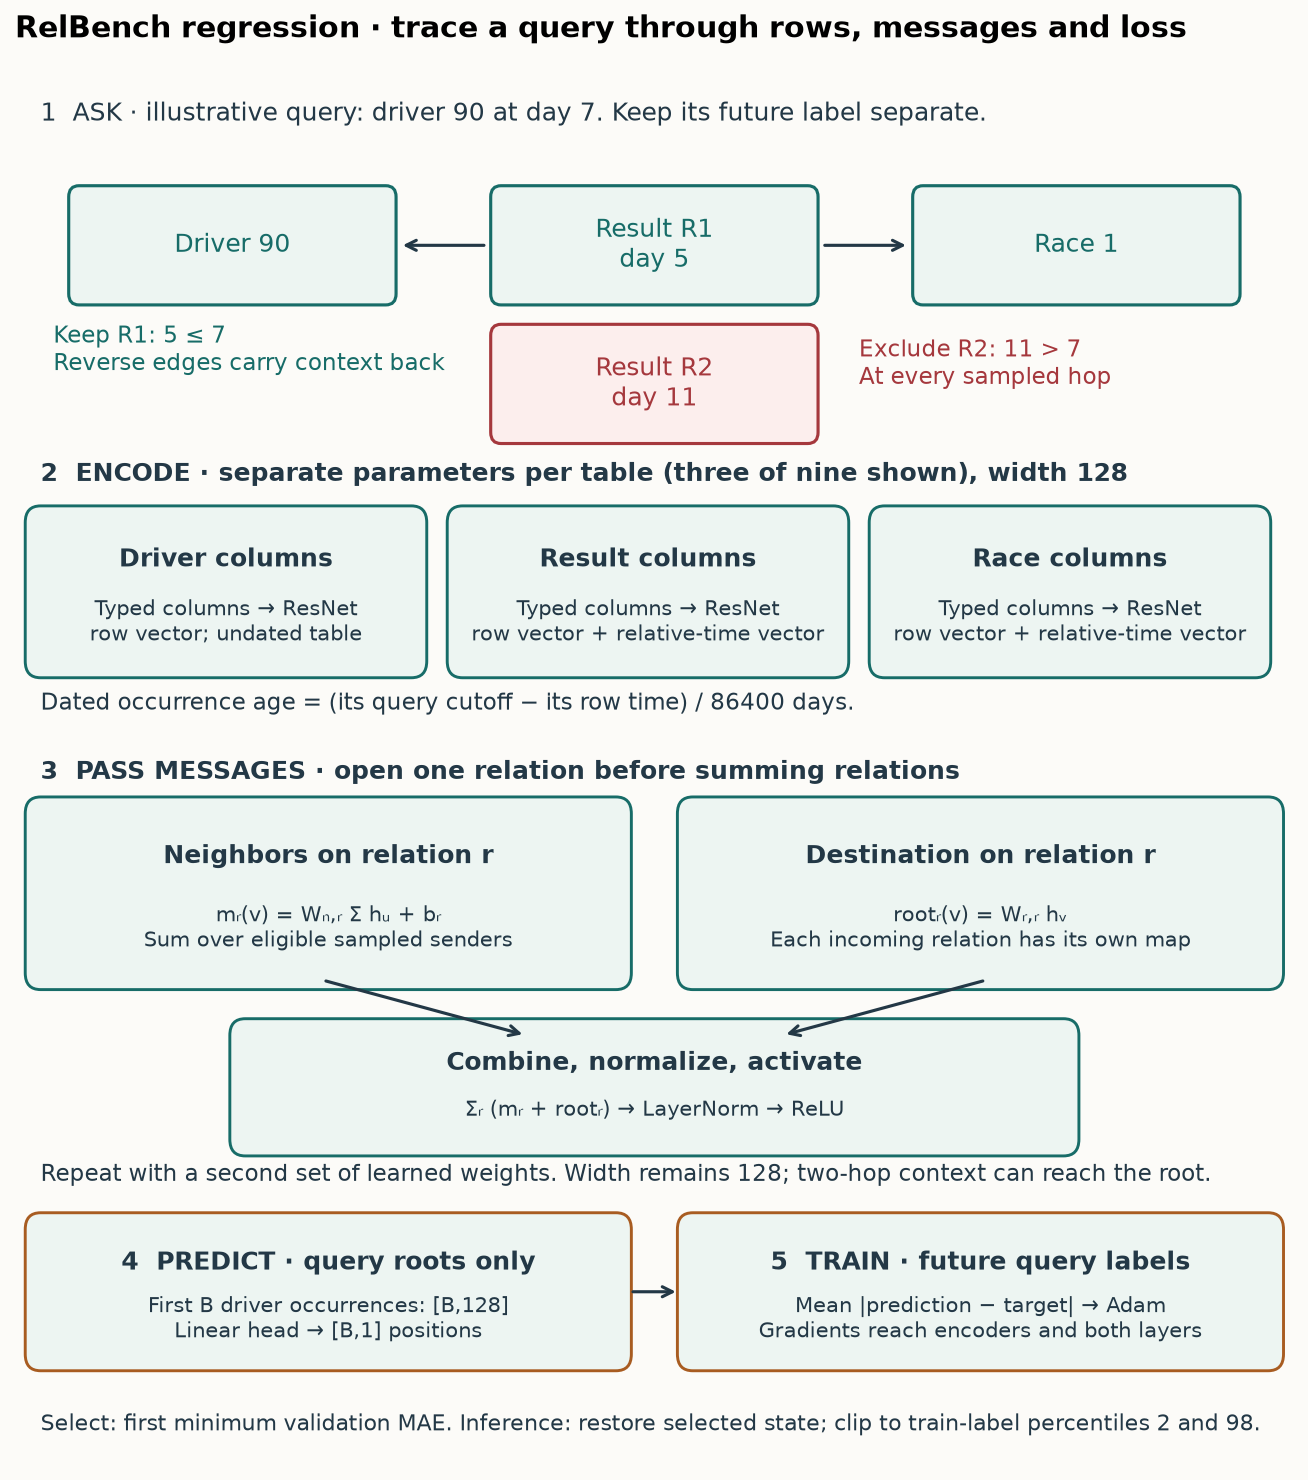<figcaption>Separate complete RelBench RDL pipeline: row encoders, relative time, typed GraphSAGE and a seed regression head. Reused L117 architecture with fresh L122 execution.</figcaption></figure>

**Diagram trace.** Follow a raw key into a row index, then from typed features to the seed head. Which construction steps can be checked without training? On a narrow screen, scroll the figure sideways.

**Forward pass:** each table's typed inputs pass through its Frame encoders and four-block row ResNet to width 128. Query-relative time contributes a temporal encoding. Two typed sum-GraphSAGE rounds use the sampled edges, relation-specific transforms and root maps, with normalization and ReLU. A scalar head predicts the seed driver's position. The loss is mean absolute error over labeled seed queries. Adam updates learned parameters; validation MAE selects the first best checkpoint. Test predictions are scored only after selection.

The full implementation and trainer are visible in the notebook appendix. Sampling uses the released fanouts `[128,64]`, batch 512; Adam uses learning rate `.005`; each of seeds 0–4 runs ten full epochs. All 7,453 training queries participate per epoch, followed by official 499/760 validation/test queries. Predictions use the released train-target percentile clipping. The complete experiment is separately gated from default notebook execution.

**Protocol boundaries:** the release's fanout differs from the paper table's single neighbor count 128. Released feature statistics use the test-censored database and are not train-only. Historical random-state/package identity is unavailable. The protocol records these facts before scores are interpreted. Predeclared comparison: absolute difference from each published mean at most 0.2 MAE, a descriptive “CLOSE” rule rather than an equivalence test.

**Fresh author-reference execution: COMPLETE selected released-protocol experiment.**

| Split | Mean MAE | Sample seed SD | Published mean | Verdict |
|---|---:|---:|---:|---|
| val | 3.188699 | 0.022461 | 3.193 | CLOSE |
| test | 4.055114 | 0.151709 | 4.022 | CLOSE |

| Seed | Selected epoch | Validation MAE | Test MAE |
|---|---:|---:|---:|
| 0 | 8 | 3.208458 | 3.999522 |
| 1 | 8 | 3.193066 | 4.066840 |
| 2 | 10 | 3.195916 | 4.263041 |
| 3 | 10 | 3.149950 | 3.846310 |
| 4 | 7 | 3.196104 | 4.099856 |

All **6,295** final predictions were independently scored. Maximum original-model output discrepancy: **3.81e-06**. Measured pilot plus full-fit worker resource estimate: **USD 0.0526**, excluding unitemized overhead. The aggregate plan caps reservations plus overhead reserve at USD 10. [Evidence](https://avistian.github.io/relational/labs/evidence/l122/summary.json).


Each seed has its own new run UUID, checkpoint hash, epoch trace, saved predictions and original-model output replay. Results from prior lessons are not used as new training evidence. Notebook rescoring is explicitly a replay of author predictions. Your learning status remains **PENDING_WRITTEN_DEFENSE** until you implement and explain the work.



## 8 · EXIT: defend the construction

Submit your three functions, graph counts, the received-amount trace, and a short written defense:

1. Explain why `[0,0]` can be an inter-table edge, and why key90 is not row90.
2. Show what changes under the person-row permutation and what stays invariant.
3. Explain the different consequences of a null FK, a dangling FK, and a junction row.
4. Give an incorrect graph with the correct edge count and explain which audit rejects it.
5. Distinguish construction parity, the full selected training result, whole-paper parity, and temporal validity.

Explain row-permutation invariance without notes. Use the raw key pairs as your evidence.

[Student lab](https://avistian.github.io/relational/labs/0122-reg-construction.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0122-reg-construction.html) · [Reference](https://avistian.github.io/relational/reference/reg-construction.html) · [Exact commands and evidence boundaries](https://avistian.github.io/relational/labs/l122-reproduction.md).

In 1, 7, and 30 days, reconstruct the two edge tensors from the raw tables without notes. Ask the agent follow-up questions about any key lookup, relation direction, source deviation, or reproduction claim you cannot yet defend.

<!-- sequence-next:start -->
**Carry this forward.** Restrict each prediction to the rows visible at its own cutoff. [Continue to Lesson 123](https://avistian.github.io/relational/lessons/0123-temporal-heterogeneous-graphs.html).
<!-- sequence-next:end -->


### PROVIDED: dependencies

In [2]:
import json
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import HeteroData

/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Task 1: preserve primary-key identity

Goal: map each valid identity to its row. Why: raw key magnitude is not a tensor index. Hint: reject ambiguity before returning a lookup. Implement this function, then run its unchanged CHECK. The toy graph and full released key-table construction call your function.

In [3]:
def key_index(primary_keys):
    lookup = {}
    for position, key in enumerate(primary_keys):
        if pd.isna(key) or key in lookup:
            raise ValueError("Primary keys must be non-null and unique")
        lookup[key] = position
    return lookup

In [4]:
def check_keys(fn):
    assert fn([90,10,300])=={90:0,10:1,300:2}
    assert fn(['z','a'])=={'z':0,'a':1}
    assert fn([])=={}
    for keys in [[1,1],[None,1],[np.nan],[pd.NA]]:
        try:fn(keys)
        except ValueError:pass
        else:raise AssertionError('Reject null or duplicate primary keys')
check_keys(key_index)
print("PASS: key_index")

PASS: key_index


### Task 2: resolve a foreign-key column

Goal: resolve non-null references without changing source-row positions. Why: deleting nulls before numbering shifts edges. Hint: use original source positions and validate parents. Implement this function, then run its unchanged CHECK. The toy graph and full released key-table construction call your function.

In [5]:
def relation_edges(primary_keys, foreign_keys):
    lookup = key_index(primary_keys)
    pairs = []
    for source, key in enumerate(foreign_keys):
        if pd.isna(key):
            continue
        if key not in lookup:
            raise ValueError(f"Dangling foreign key: {key!r}")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

In [6]:
def check_edges(fn):
    np.testing.assert_array_equal(fn([90,10,300],[10,None,90,10,np.nan]),[[0,2,3],[1,0,1]])
    assert fn([1],[None,pd.NA]).shape==(2,0)
    assert fn([],[]).shape==(2,0)
    for pk,fk in [([1],[2]),([1,1],[1]),([1],[-1])]:
        try:fn(pk,fk)
        except ValueError:pass
        else:raise AssertionError('Reject ambiguous or dangling links')
check_edges(relation_edges)
print("PASS: relation_edges")

PASS: relation_edges


### Task 3: construct typed stores, including isolated rows

Goal: assemble all typed stores. Why: an edge list alone loses isolated rows and relationship roles. Hint: create node stores first, then one forward/reverse pair per FK column. Implement this function, then run its unchanged CHECK. The toy graph and full released key-table construction call your function.

In [7]:
def construct_reg(tables, schema):
    if set(tables) != set(schema):
        raise ValueError("Schema must describe every table")
    data = HeteroData()
    features = {}
    for name, frame in tables.items():
        pk = schema[name]['pk']
        if pk is not None:
            key_index(frame[pk].tolist())
        data[name].num_nodes = len(frame)
        excluded = set(schema[name]['fks']) | {pk}
        features[name] = [col for col in frame.columns if col not in excluded]
    for name, frame in tables.items():
        for fk, destination in schema[name]['fks'].items():
            parent_pk = schema[destination]['pk']
            if parent_pk is None:
                raise ValueError("Referenced table needs a primary key")
            edges = relation_edges(tables[destination][parent_pk].tolist(), frame[fk].tolist())
            kind = (name, 'f2p_' + fk, destination)
            data[kind].edge_index = torch.from_numpy(edges)
            reverse = (destination, 'rev_f2p_' + fk, name)
            data[reverse].edge_index = data[kind].edge_index.flip(0).contiguous()
    data.validate(raise_on_error=True)
    return data, features

In [8]:
def check_graph(fn):
    tables={'person':pd.DataFrame({'id':[90,10,300],'age':[40.,20.,60.]}),
            'transfer':pd.DataFrame({'id':[7,8,9], 'sender':[10,90,None], 'receiver':[90,10,90], 'amount':[5.,8.,2.]}),
            'tag':pd.DataFrame({'id':[2,4]})}
    schema={'person':{'pk':'id','fks':{}},'transfer':{'pk':'id','fks':{'sender':'person','receiver':'person'}},'tag':{'pk':'id','fks':{}}}
    data,features=fn(tables,schema)
    assert data['person'].num_nodes==3 and data['tag'].num_nodes==2
    assert features=={'person':['age'],'transfer':['amount'],'tag':[]}
    assert len(data.edge_types)==4
    expected={('transfer','f2p_sender','person'):[[0,1],[1,0]],('transfer','f2p_receiver','person'):[[0,1,2],[0,1,0]]}
    for kind,edges in expected.items():
        torch.testing.assert_close(data[kind].edge_index,torch.tensor(edges))
        rev=(kind[2],'rev_'+kind[1],kind[0]);torch.testing.assert_close(data[rev].edge_index,data[kind].edge_index.flip(0))
    assert data.validate(raise_on_error=True)
    # Permutation changes local coordinates, never the underlying key pairs.
    tables['person']=tables['person'].iloc[[2,0,1]].reset_index(drop=True)
    other,_=fn(tables,schema)
    for kind in expected:
        actual={(int(tables[kind[0]].iloc[s]['id']),int(tables[kind[2]].iloc[d]['id'])) for s,d in other[kind].edge_index.T.tolist()}
        assert actual==({(7,10),(8,90)} if kind[1]=='f2p_sender' else {(7,90),(8,10),(9,90)})
    assert list(tables['transfer'].columns)==['id','sender','receiver','amount'],'Do not mutate input'
    # Junction rows remain nodes; repeated endpoint pairs are distinct observations.
    tables['transfer']=pd.concat([tables['transfer'],pd.DataFrame({'id':[99],'sender':[10],'receiver':[90],'amount':[12.]})],ignore_index=True)
    extended,_=fn(tables,schema);assert extended['transfer'].num_nodes==4
    assert extended['transfer','f2p_sender','person'].num_edges==3
    for value in [999,-1]:
        broken={k:v.copy() for k,v in tables.items()};broken['transfer'].loc[0,'sender']=value
        try:fn(broken,schema)
        except ValueError:pass
        else:raise AssertionError('Dangling keys must not become negative/wrapped indices')
check_graph(construct_reg)
print("PASS: construct_reg")

PASS: construct_reg


/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/torch_geometric/data/hetero_data.py:429: UserWarning: The node types {'tag'} are isolated and are not referenced by any edge type 
  warn_or_raise(  # May be intended.


### PROVIDED: a concrete row-to-graph trace

In [9]:
def course_run():
    tables = {
        'person': pd.DataFrame({'id':[90,10,300], 'age':[40.,20.,60.]}),
        'transfer': pd.DataFrame({'id':[7,8,9], 'sender':[10,90,None],
                                  'receiver':[90,10,90], 'amount':[5.,8.,2.]})}
    schema = {'person': {'pk':'id','fks':{}},
              'transfer': {'pk':'id','fks':{'sender':'person','receiver':'person'}}}
    graph, features = construct_reg(tables,schema)
    # A deliberately untrained one-hop sum, solely to reveal the edge direction.
    amounts = torch.tensor(tables['transfer']['amount'].values, dtype=torch.float32)
    received = torch.zeros(graph['person'].num_nodes)
    edge = graph['transfer','f2p_receiver','person'].edge_index
    received.index_add_(0,edge[1],amounts[edge[0]])
    torch.testing.assert_close(received,torch.tensor([7.,8.,0.]))
    return {'status':'PASS','nodes':{k:graph[k].num_nodes for k in graph.node_types},
            'edges':{'|'.join(k):graph[k].edge_index.tolist() for k in graph.edge_types},
            'feature_columns':features,'received_amount_by_person_row':received.tolist(),
            'evidence':'Course construction and untrained sum; not a benchmark score'}

## RUN · your row-to-graph construction

Predict receiver endpoints and the received-amount sum before execution. The report proves reference execution, not learner mastery.

In [10]:
report=course_run()
from pathlib import Path
Path('l122-task-report.json').write_text(json.dumps(report,indent=2))
print(json.dumps(report,indent=2))

{
  "status": "PASS",
  "nodes": {
    "person": 3,
    "transfer": 3
  },
  "edges": {
    "transfer|f2p_sender|person": [
      [
        0,
        1
      ],
      [
        1,
        0
      ]
    ],
    "person|rev_f2p_sender|transfer": [
      [
        1,
        0
      ],
      [
        0,
        1
      ]
    ],
    "transfer|f2p_receiver|person": [
      [
        0,
        1,
        2
      ],
      [
        0,
        1,
        0
      ]
    ],
    "person|rev_f2p_receiver|transfer": [
      [
        0,
        1,
        0
      ],
      [
        0,
        1,
        2
      ]
    ]
  },
  "feature_columns": {
    "person": [
      "age"
    ],
    "transfer": [
      "amount"
    ]
  },
  "received_amount_by_person_row": [
    7.0,
    8.0,
    0.0
  ],
  "evidence": "Course construction and untrained sum; not a benchmark score"
}


## Audit the real author runs

The embedded predictions are from five fresh full-data fits. They do not replace your own training evidence.

In [11]:
# PROVIDED: independently rescore all fresh author-reference queries.
import numpy as np,io,base64,hashlib
payload = {'0': {'base64': 'UEsDBC0AAAAIAAAAIQBWuRqj//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAACAcAAAAAAACdlfdXlAcWhjVqlCaCfsMw0plvvqmMKCBVfQQSxCiuCkgL4BRQEKRaEJUYRYNostg4iriyijUES1zbKnqMkpi1rDk2LBhrjsbjqkGD6M7+C3t/u+8955Zz3/veuomJEyal9O5V3qtCMltKTMVSuI8UaQ2S9D6StbC4tDi7ILOw2Gz5H/5Jdn6JxYaX5GbPtth8dVBYmF6j96n0+b/NvuOOGzWK0WRUD+KJcSyNnka2e+iJ+kZk7kMXep83crFVT1FEDltM42l8lUdL3xh8t8robqzmXj34lCyk7rGSnddCmDnDHckQQPTyDBLMVpJjk3FK9yUkVc7ZcVpa9ovUy0z0DtdxYcMEBv5FYto0FTVLM+h4lIvwcBhdBgVGdyWnnAw0esnZU65Gt8+K7wI9yjejKN3myYNvVezYrkJoiqD+ZDLhEX68/krEa6Oa31cK/OJv4Yd/qGifmUtmyFRGZ2i4Khay0aRllqqMBc9VfLJL5Oa/htAa745qq4FHN03c+qucjyqc0DhoOTQgnXPBSnJihuIiC2bx7yJjCmRUx/vQc0ZD3ZtEajaFcW+qN3G2vjv9c7h/RGKyt4VHV7R4btfSf38Cd145sD9Ijf6ByNrNIlWNBmojonnbo6XHGkmVzomWVWYa4l3x3hbKjRtuVNYm0jxKxcOooRx44U1itR/5E4fS7+I0MrLcaI/y4vllkdvBEinzRWJ9tZQ05FBvnEZPwFz65urQVM1lxB4JTXUcI9/KOF4QS1W+F4+DXEHK5HqEhhvLUvELFej+Sk9KiJrKt8GczVHy4gn8ssYDqU1G1DGBppIAutYqWWqfycUpgyjaKXKoppSddmqC/SVcl7pg3ZTJ+hAFTWdsuw0yYDdHzt33AgXLdej8P+PZqTHMjdTh8CIB6+nPaK1U8O55KnadMh60z+TQF3FU+AUy510azf3VeHREE/1gPheOwNplfvT/TcRzk8CT3UPYc82P8QXZCDPyOZE7jAl9bPPvloher+JI0Reog8MRV2pJPFyOsy1/1gAtB21xrRTD9d8cOStYeb/XgUXOEo5bPYn6Q871LjkZJ6LItlPhXOHPEpkbfXqy+XWBkoflg6i/raHgvsaWezpXR8wkL8DM8e+dWXQyhwmXJT6ebcV4zYiT1xI0Zlee7VDha3IE/SymmyTCrg1kzHee9PT25fTzJKrKLBQ+DaV9Rga7Fhv4d5kvqxnC2I0Ss5+oMXxwJ/6fJtadm05CoRb/BRrSl2hYOL6IVylyxjoHcakjk8iFIu/+1FP8LIacYCM4Kni1QcfpRAX921SsMMqpOZ3DsHEqgk/IiUvyYouXijsuNl7nGHg22g3Z10oenBGhJIQUn+Ho4gQmxufT/Y2F6rrZVIcmsrrQAReDI6NrzdyZJdLVouRZWhY1iW70OLmwUiNwr1Wk7zqT7ebdiNqVR793cpZP1xCyVUFUsJrnrWo6p3mSvmEwRmMWbXFaRgZ6cixdzYzJItEJZpamydhWbKVhdykd9201pOF07Shm0zk1ZRYtf8/NYM4UK+03tfznuD2+aXP5MUpOQEUkDz+1zZujpWixhuexAi8f66lsHMzLBoHXzWaaJ8XxbeXnOFs8ibEbSre9xNCcoXh6m6mr17LmZ4HD3QbO1Q3Ha4gcN8FMfXcgzmka/hyhxbpwOjXeE6j9wQmHXnYk7Pfn0FQVT6eJXN0VwJZVSu4cy8Y6KIwVP7ty6/twzs5zIDncje/ea0g9NoQvfxxG6KMUnGd7UhjjRpIqEeNtPZOjzYxc6M7qmfnctFPS52oytduC+fixmruhWt7oLCwqkKg+PJB+l2So5iuY5xNL8goZP61wpPhsHJvKtTxtVfFBJbH7gE3fNB6s9lczdrAXZVPVeN/SUl9g48XmcDp6RNIap7B8ZyApLwQ0go62JC0fe2XSfmMgWG0crJ2KS7o9jy0iQh8dZ5YVknbSnQzHLL7s0HHQzp0EhZ6NSRKWPBX68/7M8LYya5YjL0fKaRvux4RtCtSjlGgPedJwRUn+38xUvUnl17KJ9HM3cLpHoOJFBv0NEs16E637tVS0TWLvp7EM2CpR6GNl0z479lmVxO7wJ3+egqOnAjgYNhXvE660TPGmNCGNvuu9WeUwmKaVQzgq5eK8R41w6HOeJLnhczeZzRcEmtfN5npbDNsvpHLJLZC680G2nyGjQeFB1iOJhnYZu/MCqU4NpbNTJHtOPpUp9hxumcIgH2cur9VjiFSzN8yP3KMqQnMlMtbJkG23UDcqnqImgczbIXRMHEfnFT34CYQnCfx01wuTKMM6OpPuPzxQ2nR8Y76CrrBAEj5SsGiDRN6BdO5lqWnbYuX1SV8+NIlcOpbO8IXlaCIEirqGU9nLAdPGUkqq1RQcttLnvIp19nNYusaX/wJQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEAeoMT+P//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABfCAAAAAAAAJ1WaVRURxoFDIlKZOlWul/TLXuvr7vpBkSMjtxIXEZROSCIIND0BorAiIgxLkngQNxyxC1uGB1CjJmoY9BwjCOKShyOcctISCRER0c5Rp2MM2FiYpB59b10J/k7fU6dV/WqXtW997vfV7155py02Tm+Pkt9XtE4nJX2xZpxEZrxrgQNH6FxlS9esthWVlC+2OFk7yfbSiudwvvKYluFUxhrk8bE8To+YmXE//0b/gG3FU/9wnBM4sJAtgPHbm9CjtOF8DITJn+7GgEpa3BqzkIMnFWh4bETNZUuavXvLsWkRw00f39PMR4ckNMebO2v5/pTpcgNNGDCqzycPnKk252I+kst9j2rwq4LBXRW/TccYqrK4OM2Yd0zLupvPR+Is6u1CNUbUJ8SS98ZvlKg5nkH9VNetuPF4wo0Tg9BiZ8NPsE6tKeo0RQUh/p2q5cHwxwdHQ7Gs+aMEeCMhJ9hZnhnhcgJJ2vsPcPPvrn8qYrWsHfv/1eC7gQt2qrNyF1SgPPbFeiyVWCwMwsHOox4biqHk5JCOq/zfQPUVSbMGirBBGssQqOd6Ihw0VlfbRA1YuOKigXovxZKXBln30t6+O/Og+qBEbm1VjEWwtpFjWGEnWFqXjia8ETPsOL2zSLq64pK8EUphxfKtyAsx4DLLrE/enM94cn5Vo99z8TBHefA1l45+pJ06C/hka0y0ffzbhXhVIiC1rK4VG9Qkr6eOEwpVuDwqlKolmQiK0aCnE4dZiWZ0Bw9Hjtb5JAuL0C6rxzr1xfiznK9l09MYz6CfqdD82gLymYk4K0No4mDJy4VQiw9HJnPTu5XEG7WH2iQ4HT0ZnRJi9DzgQVXxzhhDrSiIV2PnJvCnn+V0R5BGcX4cWIcIr/n0TyJR+YBCXnv1Btuimfedg7StjIvl01tRuLYfEyJqBHBOP3SNLy5noe6NRSJ17SwPNagp96G6Tv1+P5WHD6drYa1KYE84cspCR/T28NhZeMKGjMd954qwf4EgetCEyJTTZjUJq5Z/w5H/eQxOlon47OJ85FDcuzNNwteykS/TEP4WLuUF4zsOgNxsK+VoU47A1FrTFgj5M+ub2S4Gj8T8cdjUN4+AueWJcDPZsG0UBcOtVgJJ9Mtf5yQcyul1Gd6MpwezNP3m+gZM0v0CcPG2ppCEzIEL3QciaP59koLYWB6Mi2Ta7QIz5Gga4uT/GG5rcTFWLcXt0dj9qxcH4SRw01o9VUje4yG9uktDEX/gUJETApG1FgLaRF0uxSRDzfhtYO/eMFThzR9cjw3TMTak2VCUq2B+vZlYYSXizHSuMnixNnJZnTv4TArdi5OBog59s+J4rkefB5s7NziPh3yZ+tw84EWP0424stwDTSNsfjEMhsjpsrx5WYer3wXgxOJZoz1rcaIdVZUv8fTt9seij5OKzLhcofY98SatYEEPWr/paN3d0vlqFtiQ/nbZlz/0E263UhW4bzgb7bXr3VrmG/ArZIgwpzdq0PJnhmo2mDEk1VqtDQ74Ts3GOgORO0os+jBmDBvvrDnrvmct66xJ4v9qM8kWHX6D+QL1tgciyWrzSyunvVvLnERthlPlagZmo1RkRxpaF7DgVNL0JeyFLKvHUjdF4j/rOTR0mVAt48OB9s5ZOXOJ95tC/MhHZ+JK+fkWCYPgX9VCO1581gRMp4ovFyPzdRjjptHziMN9P1WdG8Sfcpwvp5lxuELVsRB5NCZFo/w8SW/8S/jy7h47h3W2Jit37la4uXmubc0ezJxYJuC+AxWc7RHa5LIt6hVhXZHHupCzcjy12KbgUeP1gDre274LzdiQGn34mZ1449TlRi7qxAt3aEUJ09dz929APMfyZFqKMTW1HwMDdDgnR+sFBd7UhjhaL1RjNIIC3o/N4M7L/qm+Y4JsscKr+cPXxbjxfSoGSLeyYzfhJ0SvGUQ71+2F3tv/5jD3Djpb3KUadDA8UhL4NH0WizaD5tQdD3D6/+jvAsvw4WpQm6m3eUxpGkEcYsV5jYqNcTnYa6YP9HJbnTWxMAeEU1nVOUFkQ+nLI1H9U9ulBtFfrY8EedTAX/VFgXunDHAdkXkx9rVARXamP8ETjdSpMRvkVZKY9Zn357tkeOewJOtX7RdRTykr2pQJ/B6nsVROD8tVLyj9g134fhpJ0YmOnHmH8J/lL9n0vyibRqKaVOJAgs6HYhMDIJGyJPBwjjvWc33JXi7xwDZfc6LectTC/asclC+Mj4HxypwRCGj/vQzLmxwWXChQ4e6z41Y+8iMP59zEg5bdBjGfS3Wcl+tnDC/6yfFPSFXPJo2bTSQbyb9W4neLofXL30THbhYpsBMRwHC/eTYUWXDhaJgL86mz6SEnelxMXA0PvyTnvCo98rw8X09yoU8GXfUhWsVFpRvtWB6nVA7N8qIw7BbOgwOCjGcJnp82DoVYbjSFUa4mVYeXZt+b8SWAgthZnhjf/a6UluE3kshiF0kR8bCDAyYxdo2cUchAhI52je5OgyN36nh3mFAZRqPF4S6V1Oiw9++0KNr41IEBcdi+8w48J/ocO5FCyoH43HolBr23fEIFOo+02tICE+c/WolxC9dqL0e3s/WqQgj02vIT2KONHVyNPeoVwmTRir6XRifrVfiSZsc/rf1SA0wE8epA2q6n2r0boTsNGLeEKc3Lq9/ZII0IB3X07X4YXsyrWdN1xeFEwNBKIvKJ6+zNjIkHknzeMLMatAKoRYxLRhO9lzxc23adN6NGy4r8XF0SL3efuki541ryz2x7me7xPxovSzm9ImPRD964sJq2I5VQt19Q8ytsLtmXLxZCBMv5gDbQxPtwFo7j+jeIGTPVSPxcSRk+6ZA5StoOlIGm38wju7S439QSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAFa5GqMIBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAUYHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAdALAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAdUOAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAeoMT+F8IAABgDAAADQAAAAAAAAAAAAAAgAGwEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAU4aAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAGpIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABvyQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAkigAAAAA', 'sha256': '062aa5070b1c88e8e19a52127f6b0b184ca3d85804f84df129903aaa77f11e92'}, '1': {'base64': 'UEsDBC0AAAAIAAAAIQANsSqc//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAASAcAAAAAAACdlflfzYkexo+QnDpFWk77vkgpVKqxfN5oYSgqEaIdk7UaYmSaLxfJkmWIyzWDy5gwlrFOM419DSXMbSxZCiVLi5sw5tx/4T6/fZ7fnuf1vN6fdZGjR4yMb6eao/rKIzUtKyXTI8TRo1+6v4e3o0f6zMzszKQZk2Zmpqb9zw9LmpaVpvOzpiTNStPdnv7Bwd7dvR1zHf9vqXdX1cmckEiGpt0Tz7JQCmPsMb/pw9lL1sQtey0HgrwZFuZFr97puN4dQph+KpNy+nNkUaNUvFHI+SmQ41Pm4XXVkBqbvpgO+K9YrvHBfspw0hIVApziSVpozDuzDth2c+LWMTc2Povlty/teN47nokDDXj5L2MWxibwz3iFijMORKS3SnWhFUsH+HC6riuf9plyY5TC00A/gnba0KlGQ4Jvk6y6o2GR3WDmp07CVwx5Ms6d9GVONNXXSWykwogdlnhmzaLPk6k4d3FjbksCe2eo8XyQi/UpIx7/bM2228/F+Zw+BS72NAcrhBY3i0/gFbEIc6VzfAqV8c2Sf7VJ1if2JSLfiNIVbVJ5wYnNNtYETp1AXnoIpRs6kxjjR+IwBe1RG+xzZ+N/wgWzBR5I8RiW73kkV1M0LDdy5FCWGWPrHTh/Ngz7p5607okkZeN1OThA4UHBn3IrJQiPXc2yoT6KY2vMaZtuwk839cgu1dCx70fRu5VA6LBPsmBHJ2aedOFVuR0vEw34YakDpl7ZuH87ltplebyf6I7prgWYBqopPxBGzsMm8WsU1uWaU1JWKUbbEnE7a0lt0GgqYxrEq9GH+wu7Yhr+GbH91VQV+VFs25Hcfe/krvl7uW3mi62bPkbBU/DdWS4rwjVMWD6PPAtjUr01JO98LDYh0dhe6kC6iyeu9q6c/6EjaWU14nrCGiU3goUbhNZV5hiER3IxMAxpUbN/chyqxIcy62AyyUbgXu3GtfIoGts7sM4piBmDZ5FvFsyqMU50ibPF+kSrdHv5VgZMVfNryBAOfIrCuKYPMsqOr4rUVHhqMKz5B9ltA4heZsel5DyinjfJZq0rzVOsmHM2iss9T8mQsmmkWJyR1Md2fDvtk2D3Xk73aZPdH70IK9GyLdeQ+WdUDGgcQ+4hM44W1Up+R0eav3ZG71I2EeE5nOqvUF5yWd5mKaxa05mP4xQ2XOnBEfdsvMobJPiDFUX5FySzNIMht4zZ8bFSog+asbjAgot7E6mMUhhk5MnbojAKg32YldqJYZo3stLUjeFlzrz20Uc0WZxsyOKb0a4sueZGRKwnI79RiNO8lqyhHlgWJFK02Qa9WidaAodSfcAf82QDto/WMr1OzYdcCy4UvxVlUgbVH0y4t+ydWPZQ8ahSzfebVSi7vRk6oVUUtRFTSroSXmhDZZ/exL6vkzGPFe4XzmDV/nkErB1DdWm1eIZfk3Cv8YQMUeMnJpgUjyTauQPxEx+JzcVnEqlnSaFREqXXGiVnzjTa9FtkRo2WhAANZp/Zk+9lRqOrKcdfVYj57FQ2L/FA5atloa8pR5cbUNBb14lBO0xeTCWtdS7zSw3Yk62lbtNKHIfasdTAnSe/jmXrFwprb3jSfe1FSX06k1/2N8nhBwOp8HJnZpYl+W+MuJdRL7EbulO8/Z18fk2P8e6p2F+BjAPRVLcYEvf0sbx0N2HiKDWhvRS23FQxeXiz5OzzJmSXP09zmmVjgI5xoRYEmJuydE03fj6XyV7DsXQuvi5Lq6ok+WsDSkw0WEw0YvpJZzKCbLn7MQXtWn/qK6rkx/HDie93VvImqTkQ1ZPDsQ2y/ZwH15fEcN+iC7G7myW0IYI3gx2Zpss+eUgH7gyKY6q+Gq0qidVhVtzdbsrvFxyY6ptEnMqZS/t0fAp+Judft+fGTegf1SKd2s7I6vpRHK8xZ/kWU1oN7bHSs2BarTG9apzoOkJLPzMLwnp3p31JO+ZvdSboL0u0XyRju6gvmh2vZf6yblgbOHJEx5Hvvr8mt6Ld8LMezerqaqm/YEjYdC1/PEwhpPNf4tc2DqXWnbXhHdG/48WTk1b8sdiOwi5diRmq46jrFVm0pkX2rzZh076/pNFHTVuxFduDtTx4OJKt0eHUrwwhfUdvzmxplBfPkylrNWN5xWxUNS5UHY1GmRHDVn9X9KMVarNuS9wmDR2ibdkwryMGAR4M2zuSe/++Lc2uGr7MGM/6/6iZX35b3ps3yOWxk0kfaEG/2XFUVKnJix1FQdwrad2RTNHKYKRqBMZ5Lsw9HoiS+VZsPtfDeX8X7u9pkMWH/PGeo8vyVMfszQor11fL2chIfulRJglXe3L6mAmPdxngXdQF1WlHJv/YJLURCuu/C+XwkfdyaFYAciWc30/bsv1cnbgsqJe8DDUz7/0pfUp0v0q3u/LbkQS8NWJB3z6ovNvzskNXHqWGk/fJgifnY7h7w54Vqca8yEzg7ql5DHaoE/NB/Ti/+pGYjZ+Dy2tXftP1rFw3JHFbLg0FnfkbUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAP4xTu7//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAfQgAAAAAAACdVnlUk1ceBQskghtCIesXXMbQEVBRBAThXeugqEjAyNQEUBT44oYKLu1gRwmgjnY8Wq2Ky4xbXVHUKtJRPEdcahEtLoPa8VBZAiIjtghJsGAn730n0f47OeedvPe+t9x7f79339s2fWacZpaz00qnXHV6Rs68bPU4P3Vk5hh1gJ86c0n28uy0rNlLstMzaH9M2qKcDFt/jiFtaYat7R86dmTARwF+n/v93z/3kpAC7CjoIul/NuJ0uBH/mp6PFxojjlp8oXxtxKIh+Xiw0oiJs8R4lWLErplCMbUZ8aO4kH3v5o049LGFrUHHvv9tZ5aJ/E0mxeXiYchb00J6IoxwJvnIHiVGx4p4ttdEiSt8FhjRK1SBUq2R1QsT7pEa8zC8rpXBp5QDnWcYI0LQvqmsPnN+LJ46iZA/wkRGneQhCpfj59Hu2HVjLArSwhw8KGZnFzEoT0ObCuMeqBh+ipnivfqNlVCctNB+ip/OuRQtZmNo36WMJlK8gUNctS+0E3RoLjWTjjYeWokePrflqNe64pXvdLZfxH5/BNVI8aKqgXjv+xBcOY/oGGGvuPpOphFtL+3mcSi1i1CulHPWQzlcongsMveGpSeExYKO3XTQSih2imn2AxHDMzRWhspbelZXpxnxwcNmUuVcgOIhKoRMes7qG8sF/u1HOExYK8Goucmoi24lhs+USJivxl8Pydj8ycbp2PnahY2lcTlRJmL62uMwab+ZzD/Pox8/C/M+MJEpe/xRkSlF/aixSF3siqAxGjwZ4oYKLw20yznY+XAjeBw+5gHXn0JwqSgMDwKF/LHH5ftGM7FzpHm2zEPATeuh55tIZKURFTP0kHjKkPRKhw37ZFjorIL/KFscXpkIXWPHL3rUiiQI+ZMaHVo5tt4yEZp7AYlC3tZ910n8Og0OLhOrlYxjpEWEDJ86sqs1Dpsu+GLKh1aC02pErZXC5Y8GtEUoMXljOAqGeyBsyDiWE+FZAj6qt51D6U1Bf6qj9bIeC7ZJ0Z7ni6edPtAECmN+qXlOaP3iDo6NOzdFzziPv2olzw744to2DQY1eTN8tCwpvUsG9+UYB6fCN2TRlXg8HSlF5jYJts/5lXzklgjNHQ6lKXfI1cAw7L49FqZ2Pcy1UoaT6na2x0RGzxU0pHpSnHbM7UNk7H9mSwvjQ7HREhAgx9nNOnhtkbDvUXe9GQaqJ9VyfziHfd+YSGLgFJYf1cPEaPvE6MBt15j+J/96lxy8p0Cka38sj1eydfrku6B+STxuJFWT+s4xTAuPpUZoVxVCudbiyAW7DxUWmUke5AyLZ4YSK2JUrO700JXhPaORsnb2/FTUD5Ug/nArCRwwCycD37Az5jVZ2NeOz46N7rtxwUBkHVOBkw3DdZ0UQYkqPJJzGDMwEZ9G9JDcmRIcOCECvyEMx/bmInBxKF7+IPhGeqSQx23HpegaKdTtsaZlxk5fTF7Msb4eQytpeZSMBWd9Ufs4lum2e7gYqhkmQtd6X7fERTKk6+4RijksWQWnhXHYWiyBS7A3YpKMsGy9S7wr7xGrRcpyLmz5u/NC//veek7svkb/aexPfdxEbi8TPI0W+o3Gknozjat9/OWXQkxPDxLj5ws6ZOS8FnzqeAvhvm4k8qNGNP/G4/mRKpL6Qo5za9RYf1+K1UmuOPAXwfeu8XNRFfIJMr/sIK7tDWR8oIl5/eUrseA9RQ6ufqcU6J6oQNhX7uj/hzAsSxbylOJ8aPPXLU4yNF1IYdjaS2ToVZD8u/ylfCkX+71DC23T8RcaGomdm/3e+kKmw14PwXfLNriyNQKvCbE4MUeM8md6NECCdX04HPlJjS2blChbZsATXgG/Yt6Bm/pG3goRMt3iMTHWheWWw9enGaDttpIrNTzEJTxqV4rwtiSUxWVOyQtCcWi0KTgpl2HuNCmalwl5s0etwOcPzI67d3S0icWL6tFgEPopP8veRnL4uYjNoWvRfue8TiJeaCLvn1GqwZ0SNU70kcLbyxtfekoQsDnBkf9OhQakDrRhbVSgLIJDV3c1seffnbccomx8VkmFt8C8l5mIvNcPk9cPYFxT+lcSmodxo8Owp0YH828Sxs9nfYsDv1eFlaw7pULMFQErLav/KXL40tsTJlJl4/et7U1A27RO51rMXaSHF8ZfTxAzHkcalA5edP95q4XYBd80oKuVx81GHpW7JXgblMC+6/KVLKZbvER4HDQVc5t+IPScPB2mhH2vPTb/qjOosLPO4sD82ubZwal6dl4pn2ZxCylSCt54zFOHSckSlE1QYUuDD1yzJZhEkhmOHKkb9FGCl5dXdLCzV6RvJIqj7870qmQFetny5m61TY+pU5i+dPyjXelYdcZK7u/XIFbthioTj888vndo0uLXzLBTPXZ/K8LD8xzDlnOqlWgucvhvvS+Cr+tx41MpHl2XoFyvQ3dqM7tnkr7gcGz5C8KvEs602aYnxRA83Y3hfj9fonLVKBrhC4r5fY8cPNgA2fVGknvZQgbcmoWsEZlsrr81DuuOuLB1Y/qL4O/GYXurGu5iGbSD1IhNUsA7gUPQm1zU1vRGZWo43Gb3xn+eheNsvzCc+0qMOWND4b5UOK+P13MsNn2vmJjeMWKTg3fdURHDSPX6O9fB4nWxzErot2mpIqhSBQ+l7ZhrIkToWklNghr386SMY7rtvUbvp6ELDKjIVaB4/Lt3wI+tEvz7fjw2n+FQvj+EjWdlpSeOa6uIt+3tQnOdFg/3UBzcqWKYqQdRL6JaUJz2NwDtH1qgR9RLKeOTltVE7Ln9D9vdZo9rjFrAfGG4cP4Hfi2ckxKrkI/2uDyxedj8bSZy+DvBt4K32nxxewoORgsxpGsUd/AoWiuHOKKabC5UouPQALSPn4YJpyVY09tMvELqyZI+CvwPUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQANsSqcSAcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAGGBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAEQDAAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAEVDwAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAP4xTu59CAAAYAwAAA0AAAAAAAAAAAAAAIAB8BEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAGsGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABByEAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAR0lAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAPAoAAAAAA==', 'sha256': '84ae43e5c97cb8e674f596ecb20f4e3f814c96b5209e7bcb8d334de1e3f9ea0e'}, '2': {'base64': 'UEsDBC0AAAAIAAAAIQAyGruM//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAPwcAAAAAAACdlPlfDfgax8tRyK5V55w6LTrnVMdSJ3Vapu+7RSWlJJ0U7QuiaFAXY+44DWMZyja4rtFcMxoMrixjGTcj3WuZ0R2hKELDGGRetJHMuf/CfX57ntfzep7X6/m8n8/m2MSYuGRTkyUmy5TZOcVZi5T+CmVgrlbpqVDmFi76cFHGgrTCRdk5/6tPyigozjHWi/MzinKMuUqr03mqPRUrFP93WLTX9YiYiZOpPvRMLK+ZykOZO2XXtUS8cGfR2feiuNeHpgxvNmdkkjN0EvUT05hyIZC4ij6RfXsNT918GZS/FNuQUYRbhLP1gTmb/gjAR5/EmHEGdpnM4ljlINZFmdM2cTz7/uNLSkYizREq0kbpOXtdzukcRyKS9GwLNRB83JUNXeYU3nfCw28ircNkdOyUMczPQI/wIcRjDGcX2LNUMZjKNTakLZiEJiEFbbAdgyZrqWrzZFPoexEQaOCTeyPwfpWN9MosarvUnNHkUf6Lgntz5uGSLSf29Di2yLvEZ59ZU7DDg9chBlKPdIrfn18TCd5adgWncf3WG3GpwZzD3qFMmmjJ0+B+rDvjxdVoN2rnprL4EAQNMWdQZiCR8w1Yr3Mnfn0OCy+qcdZ5IgmcwYHVT8WtGjkP8zx4rHfkoZkKrTqW8O/Gc+vbKRSVtogPjLuPrX8lKp774TC4W0S9TeDlF878tcSRspbhKBfYkWg5kOkTkilbP4TddWa8VGhxi1Hz1XBbyltUHGrJpXZLMkubSzj9WM3Xw4po2Chl+/EpOHZ1iQcFgm+zpJTV/CY6p+bTsU2BeswMpj7sFjdmeZG5ScpOixBSNaPIkXjhcUFC/WJzWkr7hLOPjrlaayrupuLS1iJqAhyo+jyXaDM5JMl4c7BdJJsnU3VkMN093hRXaNjgbEXuoS5xarsbTj8n8E4bRkSTM4nX9ezIjGZViQ3p0dOp9ugVrUvSGfQ4mKr+/tyUJ5Ii82TOkAA8qgrR7Q1Gsdeo7RkVn5aYoC8YwIpWO/z7JVD8Yi6+fh9w559jeDRASvFkBw7lrGT22kmkdbjSs7WUOOcekXJwPC6zVZQfi6Az+4rY05LJq75r4nifhtaMEbx81isObhtIkPVY9tSqmfPUltdr+xFTkoP1qeH4h5sgP6ek9xs18/R5zJ+ezz/CDHQ2toqvZAYcn0tx9TEge6dFsrWElHt94nGDB6lnfxIXNxTgskyKs/amGJLtStZ8J8Iep9CkNHD6vI7D5xJ5G++PwcOOh0dM+fHffqRYjKe0dSDlumx+j8ml74E7vzYbNY3zYLvxr94kSjg62Z0iXQq4atiYqWZHx1Qiy/3Zf88WXa+S/bVScFGjtugWAUYWAqSjab/wRtQUDaVRa0Ngownu+/ypSTMloW0UJ5PkJJ2QMnJtKN/seS+WNBkIP55JVOA84lqSyUj5TVy1aRJH3+eSFDsaM2cF1+P1dC8fjDTrpYjN7xGH0p25szqdzi0dYnPiXFQ+3eLJDVcuWspxrB0LWS7ssnKm/WijuDI0ncZTvuj8VWxe5YTcxZLzAQb+oh+BZXgOWy8WcfIjaw6ftKWuKZvtejcmyD3wW5WMm9ErypdpsNt/W1QcySdJ80ZYO0fy4gsNkmYVu30cqTQ6xtJqb0ot+uP438GU7EnjeCiUnU1gYbo9Di9NOedky8IlNlwVBkZ/Pxrlo3cCy0B6KkNYs3cg48INRH5pi3anE/UHRhMfmIUyYSZ/t7gvNlXcFx9lS7H90ZGOww40/DCB6sue5EkK8JX4sqbmtXh4IYKfhtaLkQZLFuZqcWnvEr8YuS61n06olYyB0004P3saQf3GcjPIgGuAkbVr+dTH2/J98GwCzsk4GaRg9iwVQ3+YxZXhKq61NAsvZY8oPDaEbMUUdi55IyxEvchKjGVluwq9hwOaSA0r7jjRnufAnQ8mYLFczfYIV2pjdOyyN6Wy1A2/OlfiX6aSuDaEqGgJdjV2RC1VEmmWS9Dy+2JeqJoD/jM53fZIKG7a4xIu47h3LisvGbksSaLhU0/q5luTZe1DQ4uGaWfGEh0j51cjn41B9cJvbJeo/cQORaQJfG2J24cqdKvd2Fg4nc2P45ibFM2YjwXPg/ojy08jYIM9q45ksmKwO7O6Z2ASmIRWq+Kycd74uGax97IDzS4a6nKsKJvmzYCTU9m3v11IRsqI1SUz+m8yI09/iLsnuoWZVwHnNHKeZabx7qIVVqYJxOW9FQtNM/j5X4Ekf5nIiGxfduRHsn3be9HRbcrw3dZk7jZB2j8EqhwJLZRSZ17G7RttwvRjPUWed0VYmBd3zGWEtUmRDFJwe7cnymudYrmRn2OOU5ApB9B7w5+u5HhKJCrsd3eJ6ic9ov6J3HjzbtF5LJUTb/vEPOt4Wi2k1F/ww8vZ0tjvhkvzVMyKlSyt0rN45ni2Sayos0lDd38Rl272ioC7UXy+6YmYc7WI0jFqqs8YsH8hpbpyPs++k/InUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAHUQjtj//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAhQgAAAAAAACdVntUk0ceTdBW7YqAChgCCkH48lIeIREFylxUQB5FiiGiSEggKFjlYVVaS6tLtAqiUqBqpVC1tVq2rVStipxlUY9ru9pt1e3W1ge+9biILmgQQlhm0i/r/rs5Z868fjNz7/09vtS8pk2emyEUrBKs4XJNK3JKuBm+XGReGKf05fIKS94sMSzXF5bkmuh6rOGNFaah9RVLDEWmobl0miZYKVP6lvn+379XOtyq0T7CCa4zzVgeaca7ymoYw804fUSK25nrkXl/B67IzFgt98ac6WbEcvbGETPqkz9j++OLzFBwAnYHtX1x7yP3XrJrBYeW8DBE1ljJhllmqO+YsaBUhOKFGeyt1GhXNFeZkSiQ41elmY2Hy26Qoo0hOKrmcNE6FfRcU6UHnMvT2bj5Jy1qnrjjjcKnJC1bjy3SQNT4i3EgdTYKQ2MdPCjmnngxKM/pjzWYUzCN4aeYKd4vMoUMJ210neKnZ9ZM92Y2dG3jvyyk0zsID1skCFRk4lCKEO09ORh33Ig0iQJ3el1wJG4+e+/VdjVOHZdi+6Ue4q71R1urAcdD7W8FTR4ktKfz/IU5aEwZJJQr5ewyTQpD0iLsrPfC4sMzmS+obembAoadYmrbJWJ4ik/I4d+dw8YlBWZ8u85GZgZvR1ezCmP/Zh9rl65neLifgxF1zB87ZxvQ7N5HNkcE4dz+MJxt59j5CGSgZoQLs6V+KT8gYvryfrDOEyBgpBGnDxqwfPMz0sWpkBEUiMKVieiePwaJo+ZjZagrtnTrsKZeCp7P6geL8JXRHSHPgW7vJKx8yYtx4P1yIVbo4Ejj7H76IMNNx2cbreRYQAOORRoQ28yhdWwWTJM4hDSp0FkWiuJnNkLvGLXYgMYWP7zTqUaDkUN4t4XQ2PsEZubPcqsAl0fmObi8FalkHF1qvfDuni4SZotH1IlJiHs8HIVPQvDklBRzXLLRFcfheNcsXPbwwjAnLYuJ9/8iAMVH9eY5dG7bwOZUx223DDhpDUCKUYpNH0mxvPUDZlNxdZDQcfueYGbXdtnIOJ89I8COP/ohITsVPqcCGD7aZn12nRR6hjAODbtfHno3Cf5mCdp/nYSX+kegrH4u7i5VoKX5GoluSUb14hgUR5tg6JIznFS3tZcGSVrcINOQ6klx8pi/GyVj/fCx/Uxvio22iNEylO/Q4z1nCdtfksQxDFRPqqVuYCp8dluIuH0ei48lN0QIVJkduHmNaX9BdItMbJAjZp4PtioV7B5J02i49+gw4Q+3iK4fTIsf/M1INzVge4GTIxb4OrTPT4gP/qRgWOoOKXEqO4yNFXluDK+LSc7mt2Ny8XaGH8KzBsnVt3PweIqQ3XFok/1dHh+Pjb5btUCCjBPBeKgMQaUnB/1NJVLrFfjQKRVnVo6E7uwkLHzuDW9ZPEKL8pG/YDZmrtews39PstdBzyo5NCftY97XtNX+WwpvnxC2VrbpOfkmT4+tw/zwcKm9bgUniOGjtxB614u6/eMHKf587hahmN/LCkbP/kQ0rvJDRqcP7qnNcBNfI89/7iC1ZhmLud86rY58ob2y0kb4ukZ76vuDvv1k1Y8bWFzQRveoL2ltpn7l7UVqHcN2eI0Xyk7m4MpEu4Y+fjZy7uZT8svTLYjYYETvFx2kyibFpFc1cIuXYgdxQWd9OuPd9o4WrZHZWLvPRr6N6SETZvSwWl93NQ3JcR4OrqoyDmm7OCRE+CAsPA6PnAUMK8UZeFCGdR1yJJcuYdjWbpVBKzX9T/xSvpQL/92hjc6pva3CQnhu/Hfr8xIjzBp73Q1qGcPu6HPWMr4DSWL88mQRtGoJdIqpUB1V48tWDqmtudh+XY7wT7MduGndUA94oitmPsI/Hs1ii6/r+pgs7N9gI/6X9JhtzcL1C974zimZ+UX+tJ9QHNF9eWhUSfF9mwL3HtjjhstU4tk+oSPmi/uszF9Uj+8X29cpv3CVhci+EbMz9C66/vI/B0md2EJezFGqQb41DE03OKj3SYDHEtQ9ev2/OTA7F58LczHtdSX8DssQ/ds1QrkdHNqrSlYyPod7BphWlng9ypdMhMtQruweemPOmZuExuHDuwnI9s7DOg8ZZg3xS+jtJTx+z/1OKB+vxrYT9lpP2/jlYkddyirvY/xqY/sI73N6tj7VifGk9kcGvBgPz3lTHbzo+2+95sp8t8jbhNHOOfjwEwPG7ZGgqz2N7TcXK5hPl/3kDlWbDumbbxCaJ02tUkd8lTj1kwhoMMZV4ND8UOFQrQ/PYvlK+aijrKThkZXQ8ahEPb7eNBmNeSFoFClwwuIHl2oDw5F/0Q2bLuawe7bHCBnmlgMWcnkoV3hN8ytk0AzFjWeDCG2XtI54cU9dCF83G6l8lA5TjwtkE7MhTLzh0GRkqYDlONVj+k4vLP0ylGGrnWAjk0+qsHW+DBWWHJwcE4i5jQFQH9KjcbeNfWfOPgvG3glWYtDZ683cAjHDEFVk12/3C/GSfiYMe504UMwU78HfY/3jK9l4Zc0zciHKRla7GvB+aSY7Gy3TwXTJmd2rWeaBBTflKM9ToXqYDEdLQjGxkkPFeTkanQuQdl4MQ2As/hrihShLAgSl8TAMiHDKM5HVfapX3TwV883b+YNM7x99rITnPe6umGGkeu18bM+F+1MEbC853AvLdM9ZvaPzA3IRPg0aJA+iVahq5BjHmqYp7Pt0ujoX975Wok5qdPhFsFeC2v0pKFsYBPmjeGbPzgj90H2sgyjuL2I1l7ZeQTwkNg3DXDZUg2gtolpQnPx/ALq+MdsIjZs91rgGe92lmItnCB3xd/imHbN2uD2XAypErD+/yx6PvF9oDbsg6CUdX9lzUVjpC+09PVJ0dh/SO9YnGeG9UoHJKbfJggIFugY9kFMei6A7vqgpGo4tuU+If3Ig/gNQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhADIau4w/BwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAX0HAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAQcMAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAQwPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAdRCO2IUIAABgDAAADQAAAAAAAAAAAAAAgAHnEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAasaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAEGIQAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABHCUAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAA7ygAAAAA', 'sha256': '32f1420e0eba067878f4b46cb133626c791928611e904aa37a4e67b78cd5cace'}, '3': {'base64': 'UEsDBC0AAAAIAAAAIQDnNbRR//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAQgcAAAAAAACdk+tfDXgCxmuiSZI6lVKqE+WcU6foorv8vmWSVE4RHaf7jcGQotLIxFiXmdDi4/aR+yXNaiKLJozJSC7TjbGWGJIh2lBSq2jNv7DPu+f74nnzPM/WiOhwlVpbK1vra1lqWlZKpsxXKvNP95AppbL0xZlLM5MWJSzOTE37iwcnLcxK+8Sz5iVlpH3ycg8fH6VCKc2X/t/SPyztFG+yZpBe8lhU2qgIK3WgqMyPwDgZw8r6xJpJPhyY7cna5nT0Y0MozE7DcTmkH+kV0y/OY3eNL50Fa3hwXcK7yEBqDHRJbvHB91k0j7zjeW6TwJ6IIYTlDKHE0Rn5S1c6wtWcPimjum4Wyl/NeKprzhmDJHKzE8isckIZNATnYVboGfmw7t+W7CsbRVVRHP1z/BjfZ0DrD6b490u4EWXGtFehdAgNY6JNyJs6gXKNAherz8hOimP9fyX0/rEE3aI0Rh11wk06l1ULrDmRspyWWSOJiFTQE9Mu2pOGow4bj/dmDaO+fy0q4q+J8CWulNjFs6v1iXi/QZfDHoFcqTDB2F+b9iZ3xhmPZejFeJwrA2lOHYS2dCJbx8RS/cqeCnkm0g1KkuNd2LtnFrXr2kVYqRkFm8YxPNCG0D4HVh9XcdHWi2VPZ2IY2yj2PNKgu+2dOH0ymFxpl7jbPAujRaOZssOChIbhrH4o4dSkoQyOn0P2Tn2K/AYxMMwT0SWj/bKEhnEK2ndk8uJGDD0fVjI5yBnpQC6p5uZMv6pi1tBOsbQhnJAV1uz+Z4e4aPgldUF2bJk0h+SATmFb4E/z95Y8CvgCN7kxh+080dRrIWvTw7tGmxZDPxI3GPPw6FyOT6kXPRYj+UrkMGe/JbldFpR2PhX/iIqk/1PXu3UmkG+jZP8+Q9YtbRd7kxxIrIumdHgIe7xG49OoZlleODE/WSGfGs+H84PwPZTK5fuTKZK6or90BhuDXPB08CfOKJs5nwczsNiNmXdkKOy1GP5Gl+cRxkRURVHzWzqt3QEUFjugOWKOSt+SeQMFzF87jaYQKfNvrCS4qlvoPnOj4Ikth/SjyXKtFrcGFnJa9qtoKXakKccQI9Nu4fsvPT54jMfropy7+yXoFw7mXXEKjTONCFMPiL/dcWT9fSeW12TSYJFN+VUN7y40iIi8REryJQSnxjHzrCtfB+SxXt0j3qoUNO2pEd99vpiFO0xILGsUjXIpUV/ZEVA3h9odcXR0edPaoMI9xpvDBqasHDwYN40Hnd+6cOrnIYSuycRtcBbBfyppLXJB9cwFm4OJxN8bxIMSd64Xp+NwbiyH3so4uVRFX2MgCxIkVC2TcWeVCbUf7DmneCdu/r6Y+epRdE/vFjo/GrL+jSmJAX3i4ERfjm8aEE7XjPGV2zJmqg1BBydS4qRF7Oo0ktsXczw5F2nvbJxvPhdlxXViWWEaO383peWeGVvkUchk+ugVPhUfz7wWLssseLg2Bc9v34iX4YswsOsWTj+M5X3dCKRaTmR8Y0POAWtCvrwmHNsS+WmrB8EZDuj12WK7zYTqPA0ZtQYcsV3AxkM55HVZsdDcEsOXm5nx1oHgNmdq/tDgfSaB43auuHxzXfheyeZufo84PyKMbAsPno+VUtk2kjs+r0TsLS/GHtRBcVafKIdUlsycjHpSPJpiCwIWDOF2qTnNl0y5maVBUmTOd5794piBL/srBBlVuqTVaFixyxpRNxqPJkvkAxmobs1mu2OjmLfviUiJHcGSegt+aTNj7UclXSlOODYsYv/2QC7UdIqPw6N4Vn5FbNf59Kkxviz37BR84U5oYjRK5xGcqXsv7mqFM+K0jEvHNPTGGhFvtpx7o4zRqo5jSZYNY/8cg1+EAlVpInvPy1mZXy9e6L4W8klDKLwfgW5gt9jy5IpI/pR50200UassqI1REPHaFjf3kRysdCEgx54uNxs6/Lw4975PiAEZKx7KaL4dx9ofA9Eu12HDcks6zzpS05LB0eZ6cSxNSXO+murGZ2Loc1PUdxxovTefq37DsJYl8rLAGbHREINaLwqq5DRcU7BXZc2Wkjg8VtaK1vFvhI27CU1ZveK2s4S7FXLKVaPx042haUY4FetDud7mT4HJYHIXJOGvZ0XLqgwcPjiy4nI071Nn4v13J97mx7Oz576wP2VB9RYFsQpDvNrG8bhCTXn9G1FwxQb99wl0lFtxKuat2D+tU+T8vITuudZYm2vYVWzGzfIZVCZ0C8OkdMouB1A2IZIJV5TMvTadvQf6xS+Z/WL9BXMuBGlzPnQS64QdL/5jzSGjJI6/eyF2/zabqBP1okHqje9hK9TaEiwvjyQsaDwh7m+F34w47EtUHEv+jMo+SNwSyXU7GecrO8T07a9FTfmnnY0cEKfNU7kaokOuZxBFeRaUn5nI5nUSPKK8uXUpgvA1DhjOVePS7ILjA1N6TRM5oZvHY78PYmjpFDaubBdHbi1DUqgkclssxyJH0H41l009JvwPUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhALPYbOr//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAjQgAAAAAAACdVndUk1keRcY2QDSxCzgmAZIQQy+6FnxXGRw7SCAggiGUIFhRsbtYFhUdZBgXFUSZc7AfC1hAx1EGHUc5dqyj6IiUwNGhKI4ExP3e+0zW/Xdzzu98r79776+8/DgtZGpgeBeLFItV8ti4xTHJ8pFi+eh4b7lKLI9fkLwkOXr+7AXJsXF0PCB67uI4bnxxQvTCOK6vGO7rrnJWideI/++fVWRHCp5EdJC8rZF4UxaBmcOTkHc0Ep1LnfDQPgErW+OwXa/Fgd4iaIsjYRcbxexIbgJijqSyeUG2Ft3HG9kZdO2Xcz63DOT5nxIE2Hjj5y3N5MHeWbh4Ow7+Y0RQ58xgd+VPEmBMkxYv18rRZhnF2pc23iV/vPfErA8O+MccZ9B9+32EGB8zg7WfTQuCdmNvJGfVkcUb9NhS6Yib6X2w6mkwJo3UmHlQzLICESjPnraemNbgzvBTzBSv/YmPhOKkRscpfronc4eIraFjf78ykOtT3DDpNzkOnNOi6JcOInw4D7d9Z8LluJw7R4DVvkHsvu3XvFD6kxQ1NXXk8aeByMyeiw+aSHZX79NtTCPaN2rmIv66kVCulHPEZkfYnYjHyYSB+BgQwnxB14oGGwnFTjHd0IgYnkHOw/B8mY61l1XNxpJRzcT/Vgq2Froj/Azf9j82n+Ex/OCOAhslFjlFw3dtI1H1dcM1V28cb5Ow/Xt3z8D78zZsLfVLQpWQ6Wvyw8XMDmL/OAm+KeEYcd5Asn73gnu1BCR4HArG2SD0VSCuPbSB98Qg2I2TwcQno5ceHsX9sHOLGheuhyIwi48fk18u1rUTE0caZ+JTPG7arqyoJ+uLk/CNWoeIIUpU2OlQ2qnEp3NuaLjkhoNBjYSeYZEVjeB2BWw7vXGifChelBkIjT3vwkjmz+iFbcR34jwzl8oUBeOoGi1CkWUtEc4PRVS4E053s0ZUjSdSB4thKNdjboATtpWGIGLfQGx4p2ExYfl1C8NH9TZxWJEex/pUxz1GHQxKJYq6OuG7/RJEHOLX9P3YTGh7ULwbW7e7/0zGOe3vduL/UoaOEA0CPYcwfNSmbnlAtslVjENUpjXWWYch67YMI/vJcL/GGhO04Xgw3wV9Cu6Txr5h+PAoFG0vdNjxRslwUt1+uFpPGvQNTEOqJ8Vpwuxf5si+jrW83hQbtc4SKYLvaqFb48zmlUslDAPVk2p5tckV2YJ6YhUVzOKjJVcIaUuUGbdJY/rVPr5Lbtgp4PnXYPS56sLOedLbBuKMINi+ukdOHgthWuTu0eJ4lw3w6/bfWDDVofHfGslKkQPDkhUmxevr7qw9tlLA8MbOl7J+UKUOsjY59kW2EAv1THQe4HPMr4i/14TPhI3e+/HkIATskXE1yRNf1ThgaJQrWvJdMPhcGA4us0bLCCdkRPSHYFQwmuXL0GOiBmlVfN3IGMvHcWuaFJdz+bbJ19RSXjqi1c+djXmJW8jOBi1WLFEgbS+vW/FhIdaeMRB61pe61e2TYdS9CkIxzznvjGMnQqCOkaPGbQi8ciLhM7uCZJffJ5FaRxZzw3e3mPOFfde1EFNdo1/q+9Lp9SRLEsPighqdo76ktZn61bT+u008NjWXF8/2RaCruJ1paLuhibwaZyBnpsfgVXwi0iZUkJGbHNF9gxduNYtROkyAP0unM95Ta2PxzCIclUvbiP3rWnLoUx2r9d1XBSGrqLeZ6+RyJ/waKUPDjwPgVRyCXa18rlOcRYelKPRRIq8whmF73qHEErHuf+KX8qVcTO8ONdqn6+tv1BETN9O7FXVzJmYZP8dEgoCdUavg+e7iat3kLC3W9FGg5I4rJnf1RpmbFN9PT0SJiwIeixLMuGndcM8QcvkRhPJ2axZbprpe/e8kPChpIzXdEtBnqR5Pdf0hdAplflk+7C2hOLpUxKC7ZBiSOf5WV/i4KSuUoGCC0fz2bh7C+4vqoVrMj1N+ORfqyPav+T30LDr+JPgDKeplIF/mKNXA6rIXCnLEePPOHqlJMqh/DTPHfzXHK+VSIkbHKmC5QAaVvoJQbmO5uYT9royPY9YHdm/+0XlYqLHFtlH94MvdUaW+T7y5OPxpcijebozBFDslAjh+64/9Zca/9XQ7OajxwNw/hAwrteKLQoY5leNk34Pnl+ZeT1I/+5zuzbxgJL2y+Xc38KqQ8dBI3HCU47WK40XvD1QJkMv57inhtI5IhGHFHAg3yTH5+zA2P0Dqynw6wF+IQWUzkHTzPlnO5YnnSwlMd+VU1ZO0iR7Y1thmxnxyvTO2K6JZvlI+Zx81kd8EbwnjdlqLY1w9tM1zxxlHB0guKzAyNJrhKIgTQLJoFsM/O8fIci+wlc8Vk6arT8pZ3HQqRag4HGyOF51fEq6caCUN38yArrsA3ebpEVB816yJ4avXDDvVI10kgnebG8NmW9RCqn2491wgRUCsDqp/KiBbrUDQBB2aXvDvzIhHbiiPeE2qXvL/k2qsRQyDehGvH9XKpGtTiTfyrjuCYqZ4x36Odek1PRJ3GIjPUyOpiwjH2b16ttfZLhDZz23YufZnhcg3uuDeIS/E3xyKWVHeeHhKCovLcjjol8H9yCD4RaqxM78/HsSFYHmYBop/DUCZOhR5e/h83bPfg/nmzpZ6pnePO01m3raxQoaR6mXxiK9HdQfaCZ3ze8K9PVyu0zNoP/+gED0bm0j6BS80WDowjrr3Lux98klPxK33MhQ2zzH7JXWwAqcMoVB+UuHbMrD11IZNEWPAmQoSUqgHjXVq78JC8azJg2GmNYjWIqoFxZn7+T8AHY9V6PCpTsn4rAvm45xi3jy+3ezXow/5up++js9ln578d/0unp/JL7SGVY8xkCo1H6dWb+TQfIxGcTbvQ3rGaMs50OfI8D70Lhl3xQUlh+xRnRmMlY1OyPvZChlLasmYWBn+A1BLAwQtAAAACAAAACEASMv/Xf//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEABAGAAAAAAAABoGAAAAAAAAnZi7blxVFIYHE5A1CpEdX4ONMz6ei8czY88tToSQfCo6EE0KqsgitigQQTaiQUjnHajgEeAl5gHgXSgAQUTB2Ov/1rBWlIbTLO199l736/7+46cfffLpG7Vvat92nl9cf3bVeb/R+eDySaff6Fy+uPr66vzLZy+unl/c7H94/sX1xXz/+vPzry7m68PHp8N+t9/4rvG/v3rt9huVP/908x2Wt8vZyGDVNlg7FjwSHJTcM8i9YTp3T/BtwX754w833yTBnv0vxzq3In6aWp9oDR/wC38d4WmVk9vvpHx6++07/7aeaN0sL2+/R4J9QfDDR1f7RdTDjP+PnF/D30n3d8Vnv/z1l5tvKjgSn/C3mu7vCE6jfucQPRhsOJ14byi+72tdF2wkPaM/nauwK3aEbvc1+2PxzT3svi64LYifLCe7sb8R5a2Qu53WddF7R/K14725Pez/gehs6txYeh9L7/iL6Jbio0S+FUHZo2K/4X5p8ED0DtN97LIuuoXW2KMlvPh3voe+13RO+x6Pp85fkKP225lB8G65/xl/+Ou7wie7zfVrcpy4fUxvE/G/q7XsW2Fn4Z1jjnSfCBbCi53RK3wQx0fCT3zgX3X9n6Z80HW8BqWvqqdzA0HFF3apWol+IUj8wGfSu9vnH9NvhX2AtXRuxc8bHy91r4h5turF+/jhPG+anwr/DP9W3M71b3q6K/sPEr4j3T/QmryHnyzrPuceao2fQW9VELyK6xL/E965XrEj+G1/P/EBnj3BE79va/IX9afQupHyOXTxh+Xo53O8phfi8zTVD/IT/kk+1P0KO8CH6LziR5wbCs+q6D6Q3FvRju4X2B//xW84Rx0gHo6F92/F952Ix/MO8qEn8DwQxL7p3jy/mX6GrjdbF6nOtDwOTS7qDPUMP8Qum4Knnpcjn8CB5KROcn8c48XzzZboHKd6kvsVwQo9THSeeof9mh5H5DmTJ+XpKscZ/oI9C+1vx3iiX6KvqhUpnyHXcoSvxGFLesSe2J04AiL/jugs+plIbyS58RfyPn0C/GLHXe/bTD898TNN/RX8rTjeaNfjdE716D99V+yHHkb/8f5F/QX29XxNfufcIk9Q1+z8IJ53u8J3oX3s23K+DP6heCTvTZ1P+kZbgxc9Nz3vmjzY8b1Ir5blUR9XouclnRdet/swygl+p0MdGXjc2xq94Cfke+hDT3pxvyA/whf+hf7lzz5XMC/o/Gzs/Qf50OBj7+PI/6GvdXzQob6dOB2795b0veP1wM4Rz+i5F/lzObZjX+L5v57kQY/kC/IdcTyI++XY/cPkOvRzJnc96qla1Cn0Zf/Bv6RzbZ+DQt/m/XXOa8h/75U6a3jeTHRXxd+e5wH6XNsnb9D/qx+sUp1wP8RviXf8atEX272R1wnbh85ewgNd8ilzBPVhK+FHr9gV+X8/i/rBv/ET2bEapjmR/roX67vnm/s+xwS+ybdVnqcW8Rr95c+zaOfFPGznF30M/Qh1nTnI/ue6vO/5g/kC/4z9eaH/eU6i7qb3Ae//6LeJw0VfaxB86EF9t/dt8I2ddyO9WZ4r2/FcbZT6EeVh7yO5T32HXsoLxONs4Ud2Hz+Br6HHie1zfkn/+4mfdZ2fxDrh9Rt5qJv4SdY3cwl1lrxIHgIfehmk/8Ai8df0fGpr5s4Nzx/k3dA/oq/qJM17TX+/sXu8uzAnjH0f+eizDR9yH/t/28/vJ/QB61E+v7eoy0aP+ZS5+GWar9FbIXgn4vP8Lz15HsFerAuXj342+uGG1wPeM3g3i+88wut1qOt4DP849VWnbidbL/Jb9ONmyi+ve09Cj/k9Zpj2u7J7O+l50/0+6veu5EEfY/cz+tFQF8qhy8tcGPocz//4LXKRL6gD9N3N9J88hB2JwzXR3XB5mN/iPEB9aye/XncIv+DBL4gTO0dfN3J8pqdmegeDT+oZ9wvBqdcFW1NfW742uvBJXsLuR7GeuT6JO+ojdbGI/z0OgdRf/Iy8+Zfshbzp3cD1kPsI5j3qyn6aG3nf2vS5L/RXntfxn23Pa+g3vMNV6I84bMd48jljLb0PqP+vpfrjfko8NP1d7l9QSwMELQAAAAgAAAAhAGXGe9T//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAQBgAAAAAAADVAwAAAAAAAJ2YTWtTQRSGb1uhKmItUtwoZiEmrWl706Tfif3UneLGhSspNkVBrKTiRvwVbtRfa5V5hDzwEnE2J2dm7pyZ9z3nzJl8e/7y2YtXU9Xn6kvzdHjxZtTcaTT777aa7Ubz7Hz0aXTy4fX56HT4u//pyfuL4WX/xduTj8NLvbW5UbcX242vjf9u149mqj+tiKpZfuwV+bjIlSLny7x+0TtF9oq8UcbXi15LrhW5oe+7YR+9Cd/R2Ne1ImeLXCrzVrW/O9X4ua4UvV30W0Vfnhnvvyc72J2SPew8UD8647S5atzuzSJ/SpqPddmDz+lqXNbCuSm8O8K1Fv6209U8GvZuF/mjGrfzvciHRXJe8Dcvxpm2oPUWw7nQGWc+4/C6LN7hwzzsBTtHASfwMR70D4rEX7fFn/t3xH/Cm+8YN47YB2/wZ13Hy5Jwauv85pVmu/dlz/bR4cH8JF6Qzj+OF/ZrHvuBB/ppu0UHZ+OO7vhj3ZXwffJz8l5L8WnczQv4mUfaoexfDftwXgJn498L+A0CD/sarwMu85KbWmdW/c53+KPjlfXBgXzSFo7ke/I7PICXcTSejLMv1rPf+tzguSv/o+3KP/cDzuBmvOBnU5L53o/XAwf8syP8ab7/8MMD4ew4tw5u+CF8YY/9OI8Yb/zisMgnE/KC6yHmGVf0afWzH+Ob8gD84Le+x3xe42fcOC944ceOc+cr/BY/Zn+O+7vSHX/Ox9hzv+M64co8cDJ+yd9odcDJeRO/AWdwc7yD6yP5KZL9p3ue+N3WuOs1dOeDraL3JPmOuKRuXtN6zEu4JT9kn7Rj3c+OV/tbqvdcR4T0F+vpVM+lupoGruDJPlPd5v6Uf/vixe+drsZdT5s3v7cSP67nEr+pbplUB6Ab7/TOYj/Ek+t11+VzkubN8QIeqX5Ieci47Ql//AH/8Pyu5ttOT+e0P6d7FD8wD+Qb1y/O/8bPcUB8Ov/B/2I4LzwtSHIO1iUfpvrG/KV7lv0YV7+zUr20Jd1xbl66Yf1a+Jgv1x8rgQek+Wtp/fQ/Avhyn+AXPheN9ZKfO49xv5of31spb6S86Xoo1eXOf9wr//q+AadJ+cV5yfdWwnMQ/IPzGzfjYtzSu93vGfpTHl8N/pfyi/PKsfBN724asMAj+GLX+Hq/6Z6xDs/Umb4H0v8A7qfedxw7X5i/xHdH/uX4Qvd3tDqsi13j4PxwIF58LztenG+oZ/k/piV/Ia8TD6xLXnd+//tuKP3UQdRF+MVAuusmx0fK58Y5xWt6h1g3f46XDa3r+Y5jx2Ed+AJf8AP39P8Mje9/AVBLAwQtAAAACAAAACEA7YtKSP//////////DQAUAHRlc3RfdGltZS5ucHkBABAAQBgAAAAAAACUAwAAAAAAALVYS0hUYRi9QmIWCWklPRaDi8Zk6G0PcREuFINKhYKikmmcqAiVmbGgaBMhopsoKHNh0Ko3IeGmwlUWQkK0S5RBIhcRFJkLF9VtcfByuIfvn7Fmc5i58z/uOd93vu//bx48fKDpaIF3wbscbUumE6loTSRae3ZPNBaJnu5IZVLx9taOVFvy7+/18fPppP97+ky8M+l/r9y9a2tsUyxyJZL3Z5nnPVzyLtuyyvM2zs137QvBezOVyzcHsORuyc/3ZZ53Nd3/fCCAv9pGG3t8vHRkdqorgHMNFZmEj6m9TcXNPp7b8HhHLAQ/r/j4dq2Pp34XnSwK4NS36h+zpZ53bDrRMx2CLa9Hhl75OD78teFRAOv6LhZlfKxp/7DtUAgOtxa8qQ1BvJ+ad/ROY6rbx4rymWfZlQs4uHR1/biP6+brJl6E4K0vnZ0PQrB0crDwto9VO/u6C0sXvvP8WB96Kd2g08DYtepiH288ybZ+WoROrrrsv79+sj/AD/i3dMC47c1bjleF4NO6E9/LAwieLL4t3oFqfujAz5l/1oHzBTqseTk0Nle2gNAF8dZ7vbZ3JICsFyN0Y52ASh/WKdf84Hks3cAnEPFs6WSN59+xH9f8yFcnpRfrw/nEeQR9gPAb9h3oxMi6qPGsC/sVI+Ke4x/j+DnWU3wrXhW/+fqSqgfsQ8qPwCOvx3EOPhbr87yO5ePs55Z/KB9x5dfye66LQKsOAPE+2B/3A6rOY17owb6g4hnrWHFq8Q20+FX9DfPIecv8MXK8sv+wr3DcKp44fjnPgWoc1rfil/MemKtvMl8Wb4g78IZ9cN1kf3CtZ/gf88jx5sqHa/66+qTVH3AcKn5V/4D3g06KR9XXKX6BrvHJ6/A4fm6de1z14v6AfZl1dK1rnM+uuilftvKF8wSIOMO+VJ+o8oN9R+kHZN14nX/Vf1t1U51zXftwpaNr3ln+D+R6peKL6zfPjzxU/aFVL7hPxLysF+uk+kPXfpt9kBE8MLrqxXml8on7HO5vwD/7kNXHAPkcap1rmEdGjm/FI/Nm3d+o/k35E/frnOfcj+K5qiPsO4yqboBndc7nezDl86puu/Kaa9+t4tL1/IP3wj7V+Sjf+u16X8bnJtbF+r/av8oX5TeWrv8rT9S5lXXAfhFf3NfxeNd7NPZzxT/+h/k5P9R5SvVPrvcsVp651gVLJ/Yb6z5a3RNz3WadOK9UvoTXhT9QSwECLQMtAAAACAAAACEA5zW0UUIHAABMCAAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAAr5uJlKBAAAGBAAAA4AAAAAAAAAAAAAAIABgAcAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAM9HkMDFAgAAGBAAAA4AAAAAAAAAAAAAAIABCgwAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhADq5G5mdAgAAGBAAAAwAAAAAAAAAAAAAAIABDw8AAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQCz2GzqjQgAAGAMAAANAAAAAAAAAAAAAACAAeoRAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAEjL/10aBgAAQBgAAA8AAAAAAAAAAAAAAIABthoAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBlxnvU1QMAAEAYAAAPAAAAAAAAAAAAAACAAREhAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA7YtKSJQDAABAGAAADQAAAAAAAAAAAAAAgAEnJQAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAAD6KAAAAAA=', 'sha256': '05c6f7287dc2bb0259bca065bb500565aa78add9b94376c76c3be2b4735dc8ed'}, '4': {'base64': 'UEsDBC0AAAAIAAAAIQBxZjs5//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAMgcAAAAAAACdlPtbDXgex6tzup/qdDpdTp2jDqVOTjQxiOT7IreQQjRjXJKKOiUnUelyymXD7O4ozA7GJYOWxtaMFpl1aahYl0zzGI+7wbiVp21TMqpt90/Yz2+f1/P+/PJ5P8+rLCp2ZvQn5mZrzNb5L0vMTDD6j/HxD0sa4a/38U9aaVxtjE9fvNK4LPG/fHK8ITOxn2cuj89I7N8DRoSG6nV6n3yf/3vs+jrNkYydQoOhR2yri+CJ0pcXrb40zlKSv6dHvDPqeSoLZE1pEl3l07m6ZgXP2ifxpUGKQ2oxP7ybgNangPONrija9PycJuF4nT9b3kb035vYmruCMS1qRvrakzxJjfGhO1uexpNXqGFZUip1550xjXegfGwavXdN3Avzxu6GlE6ZKxGHh1DqKyHW6IVhfyEvrg7j3AdbiiKteRhrzuhwN+Imjuf0AQOhWgUvn6lY6uVFdaAZQx0KGPzal1LzVSQXFJG9zYfw4HVIm2TMiy0mJ82ZplIl4RctCDtlQ90UDY/88ugVDpjmdAjTBG9uylM5stacBnsJ2R5B6CVuLA615ly8khSNJ9supeN7YyxR6SoaHwUhXWXi1IaBPKtbxTevtLh1D8R84Qri6rtFhr0LYrM3TbtduOOgorIatndoKbabRMzETlH9Qx6H/d+K394O5eZIGY7fzqWq3pnICBknP7ZlU6qMCX1WRDSlUJtuwbgGN5oWeNDYrGL2I2fGaTQcSculyjaRvLRN9DoOIqpxAws2Kji5VrDzpj3BI8byKsqauDtvReTofB6NUpOX09/BIQmSgqEUhqv4/eBwouco+SwhnPqXSj41mbGw2IauID0vCpSc376CyrfdosPPmeFzC4iMUTCxwh7L++ao4mfR/tKaK14BrHFSkxtng8UXEtpyNUhORhLjHc7782qu6iJpy5+OtMGGLfaJRB3oFo3+iRxJnIZnSCBhn0TjstiK+wcmoNGsxdErjLsNShoGqejaYc3Nlj5xIN6BD9djuPFMxstXwVz29sROr2DMamf2RpTgKgnjvrmGxNOb2Vtmz4a9vrx540KdRzT7A9rFV9Emrse2i3u/elL/D0sCNjgx946U8mejyNYqkV1wwKvFFv+SdZQ6aJn/slfsPzqANwE+dDlkE/ZrIe61+RTGvRcJyUVI1Y5sEv39Bw2CinXskfSIhGZ3Jre2i4P7ili8Us4m/07xvNYJo4+Sa7UpHOst4MoCFY/XhVFaEUCHwQWXNjM0P3lyS3ignC9j37ws5qSuwWaxlpEtA7l30JejbsWMnG9Od4Ev2cFZxP6uZHDSIAY8jMRzio5X8bbo73nhN96OD0tVfN4so9hYwPGHrqxLcWTBVFvmZDnhtMOZEDM/tLus8G51Zc4hBS2Wek7P8OOXYRbMu1LEmfiVXK8ppmRXAuUnuoSvvFtYPCnGMtmJsmxnjgXMwiXGCl2rGXX1UnTe7jwSKxlgLeNSognHJBnfJKlQttix84Mn2seuNEQ78mDqe1EQmUpBmQ/blzuzarkbr7PlTGjN4ZyjhA1x+azesZGoUTKaKv0Yxxb+ct+L9SGDCB6XTma1icqbOqTJ78Quh/UsmSjDpAjFINPSPlvFxTIFpgwLmmfpqAnpE/qnZoiNy1DencZrXQIXL1hjqOgWu41u1F+25lBrLmmjzSg/ZEmF+WCO9ukQFhIWkMfZeB1uU104scGL6TcyWfR9KpVzu4XC5l+iVudAdoOczjQnnuq9sOjPHa5axO3UYbhceivqs8K5Lm0Xh7Ms+KxMz/G/SmhZq2Pa+lg6Df1MYcnHTZN556sj1zqX2z9aUuuxkF2LZBjWpmPz5yH0DnZm9BkNecdzCD49gJE+74X/SSneNyxZHTWKGbvsCTG0iyf7ZnCi0pXSsYr/eXZPoQcP4mR8N0/DpTBnxAF3FM1aOk4qcAsJYUSIHPu2DLLnBPNTgQVfZnjh2qKhan8OLSt7RJurlvoYI9kVHeKalZx3f1NRJclnpsGKyZEpdP9dwz9vWfO1OhB9hhvzHnsSHCQnYnshJ5v+La6kOJAULqdqm5zfnztSnKxgz3wPdv9hESVbw3l+SUNSnj+/bewVzc2ZLN2oxqM6k/ahWvZuXULJLymsPjGQmz2FKNrfCKNKTs/X7v1/seG4bb/bL87CsLBTLK2x5Yuti7l8xJaFZzvFzhAJ1t4lnGpy52dtJqa8HrH7aTQfyaUsVSbT990Ebqln0nY2kPxjljitsqRG7UJWqIpTMgnn5wXy44ohjL7mRPn6InZ83iHU8lWU3O8Ukx4EcWe2nNvJctINMirva6lOsSdwronXb8KIqbOg9EIQ5t9Ppvb5AMJyJNQMkfB0py2XarpE4Fep/Km6R6hzlzAwzAqRGERUlhUPv5XyxzcRqPPcSZLHUxbrymaNO3aTVxO4fSOyF+Z85D0EY0WXGJ66iTPBfrzYXdjvDgXLBq7n02wn/gNQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEAt+0jQP//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABUCAAAAAAAAJ1WfVhT1x0mXyS5IUERNLlJ7g3UCjrqt0XUaV6k1lqksU4ERplWsDeEKooK1QTDh+iAsVbr58QKKvr4VOd8wAcVqRZm1bYWaytoETvnZotVaXVYHeDuOXfJ7L+7z3Oe8/U757zv7/ee37mbEufNdqTIAlYFrInMyMxdtDxyki1yyuLxkdG2yMVLl69YvnDJ75Yuz8gk4zMWZudmiuO5wsKcTLEfFfPi6Ojh0TaP7f/+mEcjSvDFOQNKDniRneVGl60E4QovVh/nkLi+GA2hRVj7YyEuGnVoDvYidfBaWqKYYuzqLKHz9/lCdBYE0T2I7bNz3xyXw/Y8B+VmHuH3A7DC48GD00VImM5gxkkHPSvuX2rceL8QN3dasODzAtqe9clT+yoDjxbBiiktRrpu4lta5A6fT9snI+djVqkWKW4ZWiYImNrDIicvGMPkamyYrPXzIJjbVupAeBZ9zGN7Jk/xE8wEL68zUJykkHGCn6zpOcJQGzLmOC9HUx2HsldMCO5xYqJRj4o/eBDf50TAWhaLdBrMypa4rPqIxz2TBbooOW5fHICmejcuW730rMhyPa1Jv/1VDyovB1GuhPO1OAuGmARMqxyIb/eoaSyIbcdYPcVOMO0VeRA8bzaw2DEpi7ZN6V68nKRC15YSPMjlMfFtqT3QUEzxxLdw6ApnkVrrws9lSsR9y6G/nocszULXe90OdP+sprYkLnPCGepfXxwyNgdhXYQHbeedcMvl2JnM48RpM9xTo7FtuRr5Nx1Ykq1G8mEHBg+z+vlMfV7A4P3BUCRq0B2hhaFW0o8vLu5YvZ8j0Vn+bCXFTdrHWhR440/FmHfXhV/XsFha7cTGMhZrZvLwBPPofE9F97g5LRv2903I28Mjy21FRb+cau/oYq8U09taLHb+j0tAqZVy/LhdixeWyfBBWzKaZhtRd0aFDQyP+Dgz/jxXgPuxCVUP1YiL1uNrETvRxGclEj7ibx+HWlcR7RM/3tqUhXnFLGLTw5FTLmpgiOR/xz0VbRcESrrb+6WTcr7EBqFZY0LanFTYRg6g+EixVfXZvxs1hHK4cFqFC83JKN9mROVcI1z1KvTcSIHtphXWtj77tWtaNAxlELfZBff3LMVJ/Ha0UYEJTZIPiT8JTh/mm+9aaK02SnwINlLGu0x4IHdhtIqVtBBlohiIP4kvu55w+LpWjtUR0v2LSmGwcYHXj9vnY1JXjOi1c69b8ORWCKbGcHSfz8PUmLLeAeOhf9vHWRjqi9DZhUhoL0H9UINfC7481HBXj/Z8K8XSMYpHusDT9vnNGoq38WWJR1/u27h30ISMH5WY3OqEPkfKZW6vdK4Pnw8bObeLG4wLV0Mh1/KIKDXCcpbD/R4rlv0+VbzTKhyIN2KK2YCMUyLmAR5UlGtxZr8UvzKdpOMQxoqxIVLbF2tSjh5jceMqR8emViuwcacLdStN2N2WRP2W8gaDpgY53etZvw26w2JLe7+dYD6cbESCMQW7HxqxatYQ7FAUwJv+1P59Tb/9t+9xVHN7dGr/fSH1bzRqf14jNYn9vUUKeOMKqS5IIXMkliQ3k7j67NPqJGxHmhloup3Yc1zKU//YIsf9lXLkhRThgkNA9KU+u6XRAqaPRx147P1CjfosKe995Xbj7DtOMIEGtE+SQZMno3smXE7Cle1aP9d7Z8xIEUv9BgMCWjUYEaGkWAnO63oOoZdZxOyXcputi0Wy1/UL/RK+hIvv3SGF9Il90TCFn5vv3Ro0IwtP6yVNrNigoXuoRkp892YwGNnuROmrJpzbxUG2i0fUQQ4prwlo2GXB5kmCHzfJG6//pIXjjw6oXlJTbfnyetpnHgRpgnB8soDHFgHGGAOOfaqhcckcFEhxeM65YK9iYT1iRe94STdl0WbUzNX7Nf/THClexB8Z1dI44Vc1VIErVQxdQ/Yi43WPGER1yn9xR4kPHl/nkdhhRneHAU+fM2HBD6l+/WelC0iNFdC0lEPgIxOM1QGUW6c4p4/nKJ/k3QzWifuP2ebG0ReGYGmslIt0rn470WFHpBb2M1noesxSfsH7VNSe4N8uvmc5Y3hsM0j8SIkJ01HMaSInoUjiNytfQfukTdbKlAbKk9iXljNIFnnM/JDz8yLne16TYldTIaD3VwKWxQkI+5sR47an0vnVqRyN6Vu5WpwdPB/vegLoPRnYbPafZeaVOFHIQ3nS4MccmMMi6pGT3lfCp25EILbmBdL2E7UL+WYWE8N5eB9Z0flPE073uiQdviRqd2AW3eev64Mo5sYw6a74fLpVacVDUTd3j2ux40AS9S+xn/6RGOtqHQ42OxCbo0aHyKWstdfuw9n1jpJiJ/5I+FLMlad4imfJJ6Kv7byYQ2243u+EcZuYMyawkI8W35SL0juzOo9DwSklIk9KGnd8wFAMIask/z2rl6vi/5BjpZliJng7/6v1bgi4PUaOsdP12LHfiU3RHrr27HwHCv6ulv7FOrX4cBGHww4eMxvDkd3HoVUu5oW7LMYOEv+NYsKwb58aSYeC0aHRoNXIwLpkIJaM02CQmPeJv7Yc4Glsdn+noPwuLQv08/6qk6EYib8qO3S0jmgKonONNQzMsQq6B+lfbGOQ8Bcl1r/J44c1EZSjJoCn79OKRAGxV8147kXBH5fcPiOUM1PxaXQI8sX/GGJPyrruMMi2B+DOSIHmXFKq92ng8vIUM8lBJBcRXxCcvn8AMi5TZqFmE0v5tFxR+LV9aJTBr7/4aRLmrUHS/bjTKt3pPdBTW19cqsQcdqRHvNuJQXT8QroJMa+40BovxZDscWKmgNX9LPSVvXZbCYektFB8U5uMW9VGHG5RYfhaGUZ6LfgPUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQBxZjs5MgcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAFwBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAH6CwAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAH/DgAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhALftI0BUCAAAYAwAAA0AAAAAAAAAAAAAAIAB2hEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAFtGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIAByCAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAd4kAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAALEoAAAAAA==', 'sha256': 'b2cfc6d462aab6532c1032dd430115416612e575b06a2b51b3ed74c73e62f352'}}
expected = [{'seed': 0, 'selected_epoch': 8, 'val': 3.208458155349803, 'test': 3.999521955858197}, {'seed': 1, 'selected_epoch': 8, 'val': 3.193066489704466, 'test': 4.066840123377348}, {'seed': 2, 'selected_epoch': 10, 'val': 3.195915863811771, 'test': 4.263040832385682}, {'seed': 3, 'selected_epoch': 10, 'val': 3.149949916171964, 'test': 3.846310005271644}, {'seed': 4, 'selected_epoch': 7, 'val': 3.1961035814457284, 'test': 4.099856423411453}]
for seed,item in payload.items():
    raw=base64.b64decode(item['base64']);assert hashlib.sha256(raw).hexdigest()==item['sha256']
    arrays=np.load(io.BytesIO(raw),allow_pickle=False)
    for split in ['val','test']:
        ids=list(zip(arrays[split+'_entity'].tolist(),arrays[split+'_time'].tolist()))
        assert len(set(ids))==len(ids)
        prediction=dict(zip(ids[::-1],arrays[split+'_pred'][::-1].tolist()))
        mae=sum(abs(prediction[key]-float(y)) for key,y in zip(ids,arrays[split+'_target']))/len(ids)
        assert abs(mae-expected[int(seed)][split])<1e-12
        print(seed,split,mae)
print('6,295 fresh author query predictions rescored; this cell does not train.')


0 val 3.208458155349803
0 test 3.999521955858197
1 val 3.193066489704466
1 test 4.066840123377348
2 val 3.195915863811771
2 test 4.263040832385682
3 val 3.149949916171964
3 test 3.846310005271644
4 val 3.1961035814457284
4 test 4.099856423411453
6,295 fresh author query predictions rescored; this cell does not train.


## Rebuild the complete real F1 topology

Your same constructor now consumes all released key rows. This embedded key-only input retains every row; it excludes feature payloads. Compare each edge with the independently SQL-verified topology. Hashes pin the input and oracle.

In [12]:
# PROVIDED harness: learner construct_reg is used on all real key rows.
import gzip,base64,hashlib,io
key_bytes=base64.b64decode('...')
assert hashlib.sha256(key_bytes).hexdigest()=='dd714e73202b369cd935baa21f922fa17a57d5c5191273f93c4bd0157d600a81'
fixture=json.loads(gzip.decompress(key_bytes))
tables={name:pd.DataFrame(v['data'],columns=v['columns'],index=range(v['row_count'])) for name,v in fixture['tables'].items()}
full_graph,unused_feature_names=construct_reg(tables,fixture['schema'])
raw=base64.b64decode('...')
assert hashlib.sha256(raw).hexdigest()=='001cc5484522580af0310a33c7391361b3edcc5ea6821f29824ea8ecf293bb16'
oracle=np.load(io.BytesIO(raw),allow_pickle=False)
for name in full_graph.node_types:
    assert full_graph[name].num_nodes==int(oracle['nodes_'+name][0])
for kind in full_graph.edge_types:
    np.testing.assert_array_equal(full_graph[kind].edge_index.numpy(),oracle['|'.join(kind)])
assert sum(full_graph[n].num_nodes for n in full_graph.node_types)==74063
assert sum(full_graph[k].num_edges for k in full_graph.edge_types)==338842
print('PASS: every released F1 row and all26 typed edge stores; key-only construction, not fitted features or temporal safety.')


PASS: every released F1 row and all26 typed edge stores; key-only construction, not fitted features or temporal safety.


## Full published implementation and trainer · PROVIDED

Unchanged pinned RelBench release model/trainer from L117, freshly executed in L122. This differs from the small course model. Source and MIT licenses: [manifest](https://avistian.github.io/relational/labs/sources/l117/manifest.json).

### PROVIDED · Key identities (PROVIDED)

In [13]:
import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [14]:
def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [15]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [16]:
def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [17]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

### PROVIDED · Relational node predictor (PROVIDED)

In [18]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [19]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### PROVIDED · Full released-protocol training loop (PROVIDED)

In [20]:
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

### Released primitive · resnet.py

Read-only source of the installed library operator, shown for inspection.

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

### Released primitive · sage_conv.py

Read-only source of the installed library operator, shown for inspection.

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

## Full five-seed reproduction · OFF by default

Requires the exact pinned GPU runtime in the contract, including native pyg-lib. The notebook gate does not enforce a monetary cap; the supplied Modal runner does reserve bounded compute. No historical environment or live Colab claim is made.

In [21]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    assert torch.cuda.is_available(), 'Use the documented compatible GPU environment'
    import pyg_lib
    for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
        assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    records=[fit_rdl(data,stats,task,seed,Path('l122-full')/f'seed-{seed}',10,'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in range(5)]
    print({s:float(np.mean([r['scores'][s] for r in records])) for s in ['val','test']})
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.


## EXIT

Submit your graph, implementations, executed artifacts, evidence labels and five written answers from the lesson. Passing checks alone leaves PENDING_WRITTEN_DEFENSE.